# PROJETO 2 ANADI - E-REDES

In [2]:
# TODOS OS IMPORTS SÃO FEITOS AQUI PARA MANTER SIMPLICIDADE
import matplotlib.pyplot as plt
import json
import joblib
import pickle
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import f_oneway, shapiro, wilcoxon, ttest_rel
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVR, LinearSVC
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

In [3]:
ptd_df = pd.read_excel("./data/PTD_level_dataset.xlsx")

#### Helpers

In [4]:
def print_table(headers, rows, align=None, float_fmt=".4f", title=None):
    """
    Print formatted text tables.
    """

    # Infer alignment if not provided
    if align is None:
        align = [];
        for col in zip(*rows):
            if all(isinstance(v, (int, float)) for v in col):
                align.append(">");
            else:
                align.append("<");

    # Format values
    formatted_rows = [];
    for row in rows:
        formatted = [];
        for val in row:
            if isinstance(val, float):
                formatted.append(f"{val:{float_fmt}}");
            else:
                formatted.append(str(val));
        formatted_rows.append(formatted);

    # Compute column widths
    widths = []
    for i, h in enumerate(headers):
        col_values = [r[i] for r in formatted_rows];
        widths.append(max(len(h), *(len(v) for v in col_values)));

    if title:
        print(f"\n{title}");

    # Header
    header_line = "  " + " ".join(
        f"{h:{align[i]}{widths[i]}}" for i, h in enumerate(headers)
    )
    print(header_line);

    # Separator
    sep_line = "  " + " ".join("─" * w for w in widths);
    print(sep_line);

    # Rows
    for row in formatted_rows:
        print(
            "  " + " ".join(
                f"{row[i]:{align[i]}{widths[i]}}"
                for i in range(len(headers))
            )
        );

#### Perfis de configuração

In [5]:
# Configuração global da análise
CFG = {
    # Geral
    'name':             "Default",
    'random_state':     32,
    'kfold_splits':     5,
    'sample_viz':       2000,

    # Subsampling (None = usar dataset completo)
    # Reduzir para testes rápidos; None para resultados finais
    'sample_cv':        15_000,   # amostras usadas no CV dos modelos lentos
    'sample_loss':      5_000,    # amostras para curvas de loss das NNs
    'sample_lc':        15_000,   # amostras para learning curves

    # Árvore de Regressão
    'tree_max_depth':       10,   # profundidade do modelo treinado
    'tree_viz_depth':       3,    # profundidade da árvore visualizada

    # SVM
    'svm_configs': [
        {'name': 'LinearSVR C=0.1', 'C': 0.1},
        {'name': 'LinearSVR C=1.0', 'C': 1.0},
        {'name': 'LinearSVR C=10',  'C': 10.0},
    ],
    'svm_max_iter': 3000,

    # Rede Neuronal
    'nn_configs': [
        {
            'name':                 'Rasa (1 camada, sem reg.)',
            'hidden_layer_sizes':   (64,),
            'alpha':                0.0001,
            'learning_rate_init':   0.001,
        },
        {
            'name':                 'Média (2 camadas, L2 moderado)',
            'hidden_layer_sizes':   (128, 64),
            'alpha':                0.001,
            'learning_rate_init':   0.001,
        },
        {
            'name':                 'Profunda (3 camadas, L2 forte)',
            'hidden_layer_sizes':   (256, 128, 64),
            'alpha':                0.01,
            'learning_rate_init':   0.001,
        },
    ],
    'nn_max_iter':              150,
    'nn_early_stopping':        True,
    'nn_n_iter_no_change':      10,
    'nn_validation_fraction':   0.1,
}

In [6]:
# Enum de perfis
class Profile:
    LEVE = "profiles/leve.json"
    MEDIO = "profiles/regular.json"
    PESADO = "profiles/pesado.json"

PROFILE = Profile.LEVE;

with open(PROFILE, 'r') as f:
    perfil_cfg = json.load(f);

CFG.update(perfil_cfg);
print(f"Configurações do perfil '{PROFILE}':")
for k, v in perfil_cfg.items():
    print(f"  {k}: {v}")

Configurações do perfil 'profiles/leve.json':
  name: Perfil Leve
  sample_cv: 5000
  sample_loss: 1000
  sample_lc: 5000
  nn_max_iter: 50
  kfold_splits: 3


#### Carregar resultados pre-persistidos

In [7]:
FORCE_RETRAIN = True

result_path = os.path.join("results", f"{CFG['name'].replace(' ', '_')}", "results.pkl")
if not FORCE_RETRAIN and os.path.exists(result_path):
    print(f"Resultados pré-existentes encontrados em '{result_path}'")
    with open(result_path, 'rb') as f:
        results_all = pickle.load(f)

    model_lr = joblib.load(os.path.join("results", f"{CFG['name'].replace(' ', '_')}", f"{CFG['name'].replace(' ', '_')}_model_lr.pkl"))
    model_tree = joblib.load(os.path.join("results", f"{CFG['name'].replace(' ', '_')}", f"{CFG['name'].replace(' ', '_')}_model_tree.pkl"))
    best_svm = joblib.load(os.path.join("results", f"{CFG['name'].replace(' ', '_')}", f"{CFG['name'].replace(' ', '_')}_model_svm.pkl"))
    best_nn = joblib.load(os.path.join("results", f"{CFG['name'].replace(' ', '_')}", f"{CFG['name'].replace(' ', '_')}_model_nn.pkl"))
else:
    print("Nenhum resultado pré-existente encontrado. Iniciando treinamento...")

Nenhum resultado pré-existente encontrado. Iniciando treinamento...


## 4.1 - Análise Exploratória de Dados

In [8]:
print(f"Número de registos (PTDs): {ptd_df.shape[0]}");
print(f"Número de variáveis: {ptd_df.shape[1]}");

print("\nTipo de dados:");
print(ptd_df.dtypes)

print("\nValores omissos:");
missing_count = ptd_df.isnull().sum();
missing_pct = (missing_count / len(ptd_df) * 100);
missing_df = pd.DataFrame({
    'Variável': missing_count.index,
    'Omissos (n)': missing_count.values,
    'Omissos (%)': missing_pct.values
});

print(missing_df[missing_df['Omissos (n)'] > 0]);

print("\nResumo estatístico: ");
print(ptd_df.describe())

Número de registos (PTDs): 72027
Número de variáveis: 32

Tipo de dados:
Distrito                         str
Concelho                         str
CodDistritoConcelho            int64
Código de Instalação             str
Coordenadas Geográficas          str
Potência instalada [kVA]       int64
Tipo Construtivo                 str
Cap_PTD_kVA                    int64
Pot_Contratada_kVA           float64
N_Clientes                     int64
Pot_Geracao_kW               float64
N_Clientes_Produtores          int64
P_IP_Total                   float64
P_IP_Inef                    float64
Rate_Ineficiencia            float64
LED_Ratio                    float64
N_Luminarias                   int64
N_Lampadas                     int64
N_PTDs_Concelho                int64
PVE_PTD                      float64
D_PTD                        float64
IP_per_PTD                   float64
IP_Inef_per_PTD              float64
Ganho_LED_PTD                float64
D_PTD_LED                    float64
Ca

### 4.1.2 - Análise de Distribuições

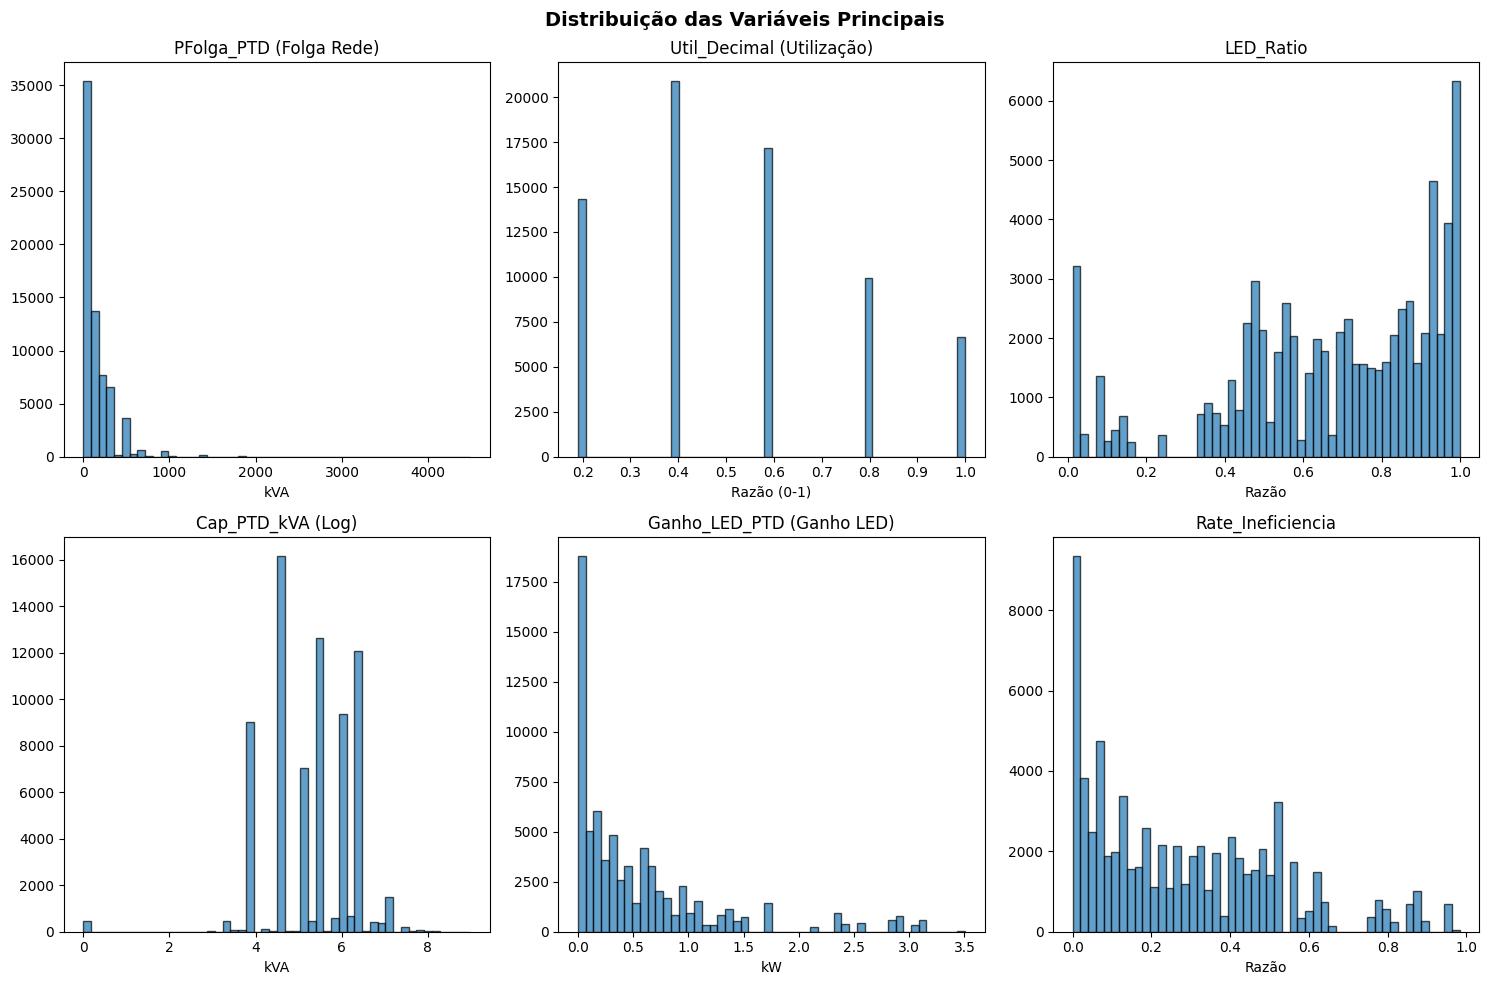

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10));
fig.suptitle("Distribuição das Variáveis Principais", fontsize=14, fontweight='bold');

# Distribuição de PFolga_PTD
axes[0, 0].hist(ptd_df['PFolga_PTD'].dropna(), bins=50, edgecolor='black', alpha=0.7);
axes[0, 0].set_title('PFolga_PTD (Folga Rede)');
axes[0, 0].set_xlabel('kVA');

# Distribuição de Util_Decimal
axes[0, 1].hist(ptd_df['Util_Decimal'].dropna(), bins=50, edgecolor='black', alpha=0.7);
axes[0, 1].set_title('Util_Decimal (Utilização)');
axes[0, 1].set_xlabel('Razão (0-1)');

# Distribuição de LED_Ratio
axes[0, 2].hist(ptd_df['LED_Ratio'].dropna(), bins=50, edgecolor='black', alpha=0.7);
axes[0, 2].set_title('LED_Ratio');
axes[0, 2].set_xlabel('Razão');

# Distribuição de Cap_PTD_kVA
axes[1, 0].hist(np.log1p(ptd_df['Cap_PTD_kVA'].dropna()), bins=50, edgecolor='black', alpha=0.7);
axes[1, 0].set_title('Cap_PTD_kVA (Log)');
axes[1, 0].set_xlabel('kVA');

# Distribuição de Ganho_LED_PTD
axes[1, 1].hist(ptd_df['Ganho_LED_PTD'].dropna(), bins=50, edgecolor='black', alpha=0.7);
axes[1, 1].set_title('Ganho_LED_PTD (Ganho LED)');
axes[1, 1].set_xlabel('kW');

# Distribuição de Rate_Ineficiencia
axes[1, 2].hist(ptd_df['Rate_Ineficiencia'].dropna(), bins=50, edgecolor='black', alpha=0.7);
axes[1, 2].set_title('Rate_Ineficiencia');
axes[1, 2].set_xlabel('Razão');

plt.tight_layout();
plt.show();

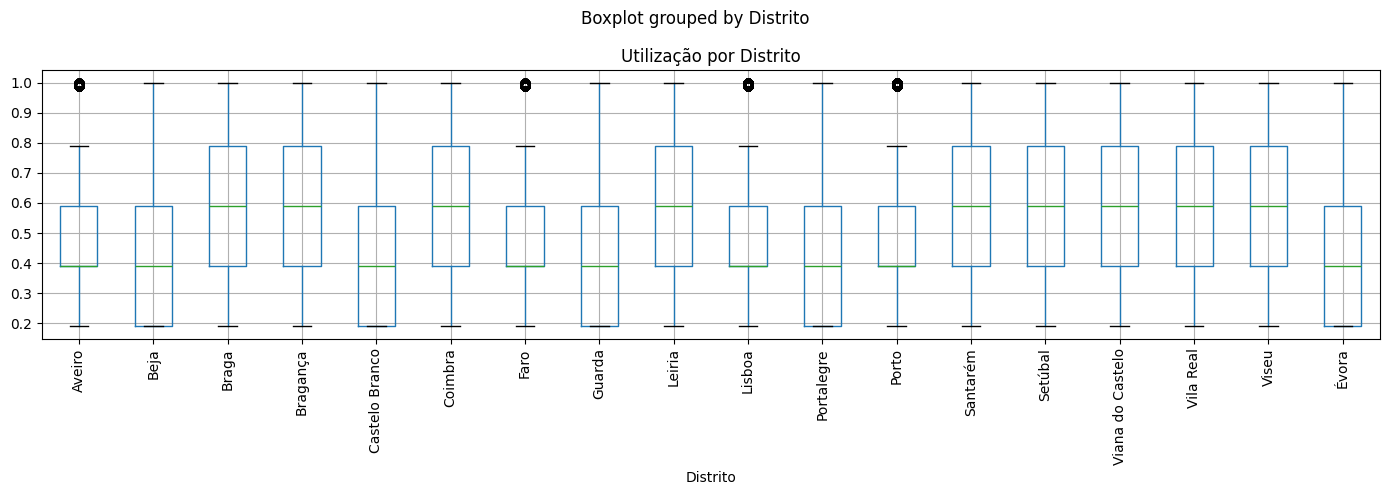

In [10]:
fig, ax = plt.subplots(figsize=(14, 5));
ptd_df.boxplot(column='Util_Decimal', by='Distrito', ax=ax, rot=90);
ax.set_title('Utilização por Distrito');
plt.tight_layout();
plt.show();

Heatmap de correlação
PFolga_PTD                   1.000000
D_PTD                        1.000000
D_PTD_LED                    0.999979
Cap_PTD_kVA                  0.806477
Potência instalada [kVA]     0.806477
Cap_per_Cliente              0.632685
P_IP_Total                   0.147729
N_PTDs_Concelho              0.127164
PContratada_per_Cliente      0.108579
Pot_Contratada_kVA           0.087915
P_IP_Inef                    0.061536
IP_per_PTD                   0.055998
N_Clientes                   0.054174
CodDistritoConcelho          0.053210
Clientes_Produtores_Ratio    0.053142
N_Lampadas                   0.046996
N_Luminarias                 0.046492
Geracao_per_Cliente          0.033846
Ganho_LED_PTD                0.029368
IP_Inef_per_PTD              0.029368
Rate_Ineficiencia           -0.012273
Pot_Geracao_kW              -0.025849
N_Clientes_Produtores       -0.047034
LED_Ratio                   -0.054994
Util_Decimal                -0.832147
PVE_PTD                     

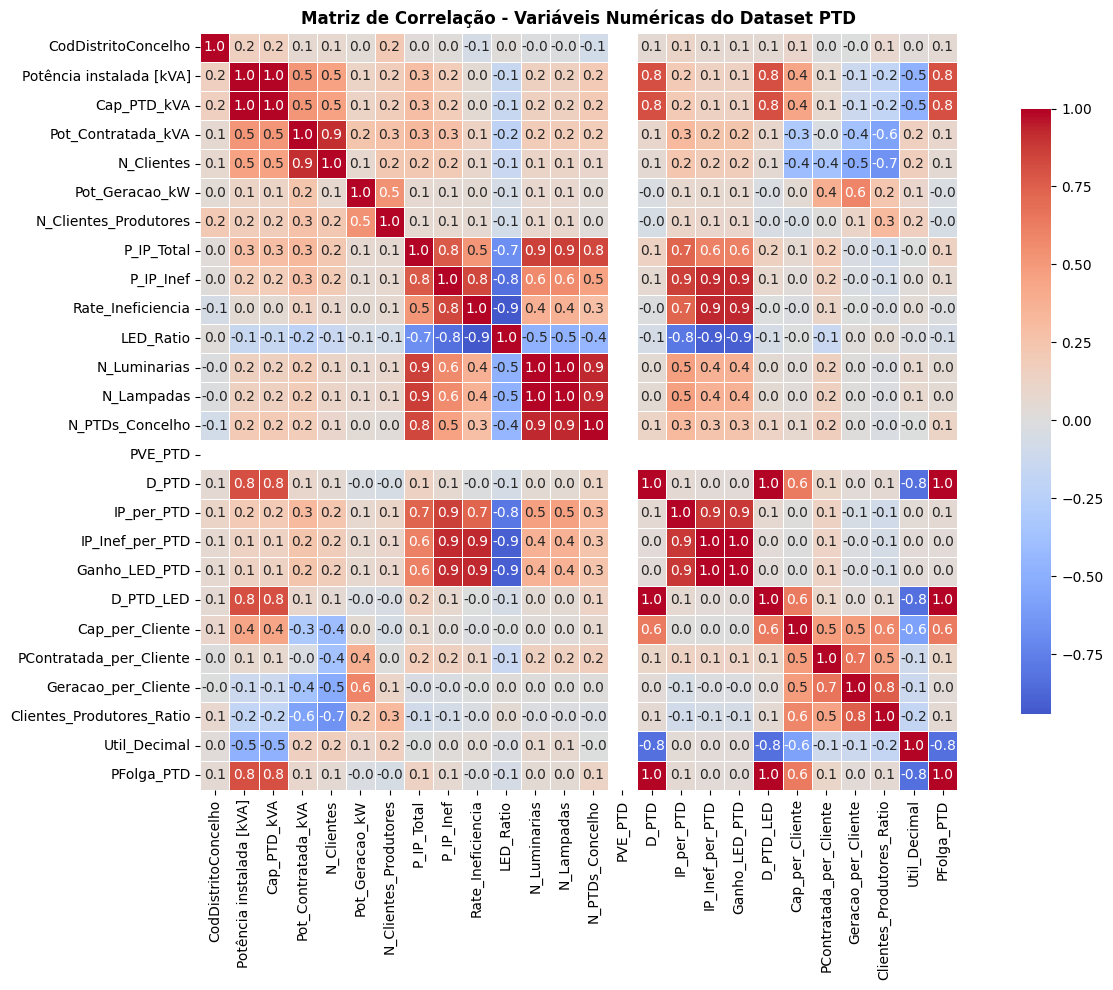

In [11]:
# Selecionar variáveis numéricas para correlação
numeric_cols = ptd_df.select_dtypes(include=[np.number]).columns;
numeric_df = ptd_df[numeric_cols].dropna();

# Calcular correlação com PFolga_PTD
correlation_with_target = numeric_df.corr()['PFolga_PTD'].sort_values(ascending=False);

print("Heatmap de correlação");
print(correlation_with_target);

fig, ax = plt.subplots(figsize=(14, 10));
corr_matrix = numeric_df.corr();
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax, fmt=".1f");
plt.title("Matriz de Correlação - Variáveis Numéricas do Dataset PTD", fontsize=12, fontweight='bold');
plt.tight_layout();
plt.show();

### 4.1.3 - Pré-processamento dos dados

#### Selecção de variáveis relevantes

In [12]:
# Removidas:
#   - Identificadores sem poder preditivo: Código de Instalação, CodDistritoConcelho
#   - Redundantes: Cap_PTD_kVA == Potência instalada [kVA] (duplicado)
#   - Coordenadas Geográficas: texto livre, sem geocoding
#   - Nível de Utilização [%]: versão string de Util_Decimal (redundante)
#   - Pot_Geracao_kW / Geracao_per_Cliente: 97% omissos
#   - N_Clientes_Produtores: near-constant (75th pct == min == 20)
#   - Clientes_Produtores_Ratio: derivado de N_Clientes_Produtores
#   - Pot_Contratada_kVA / PContratada_per_Cliente: 29% omissos
#   - N_PTDs_Concelho / IP_per_PTD / IP_Inef_per_PTD: agregados de concelho,
#     não propriedades do PTD individual

cols_to_drop = [
    'Código de Instalação',
    'CodDistritoConcelho',
    'Coordenadas Geográficas',
    'Nível de Utilização [%]',
    'Cap_PTD_kVA',
    'Pot_Geracao_kW',
    'Geracao_per_Cliente',
    'N_Clientes_Produtores',
    'Clientes_Produtores_Ratio',
    'Pot_Contratada_kVA',
    'PContratada_per_Cliente',
    'N_PTDs_Concelho',
    'IP_per_PTD',
    'IP_Inef_per_PTD',
];

df = ptd_df.drop(columns=cols_to_drop);
print(f"Variáveis após seleção: {df.shape[1]} (removidas {len(cols_to_drop)})");
print(f"Variáveis mantidas: {df.columns.tolist()}");

Variáveis após seleção: 18 (removidas 14)
Variáveis mantidas: ['Distrito', 'Concelho', 'Potência instalada [kVA]', 'Tipo Construtivo', 'N_Clientes', 'P_IP_Total', 'P_IP_Inef', 'Rate_Ineficiencia', 'LED_Ratio', 'N_Luminarias', 'N_Lampadas', 'PVE_PTD', 'D_PTD', 'Ganho_LED_PTD', 'D_PTD_LED', 'Cap_per_Cliente', 'Util_Decimal', 'PFolga_PTD']


#### Tratamento de valores omissos

In [13]:
# D_PTD, D_PTD_LED, Util_Decimal, PFolga_PTD: ~4.25% omissos
# São variáveis target, não podem ser imputadas então removemos as linhas

print(f"\nRegistos antes de remover omissos nas targets: {len(df)}");
df = df.dropna(subset=['D_PTD', 'D_PTD_LED', 'Util_Decimal', 'PFolga_PTD']);
print(f"Registos após remoção: {len(df)} (removidos {72027 - len(df)}, {(72027 - len(df)) / 72027 * 100:.1f}%)");

remaining_missing = df.isnull().sum();
print(f"\nOmissos restantes:\n{remaining_missing[remaining_missing > 0]}");


Registos antes de remover omissos nas targets: 72027
Registos após remoção: 68963 (removidos 3064, 4.3%)

Omissos restantes:
Series([], dtype: int64)


#### Transformação de variáveis categóricas

In [14]:
# Tipo Construtivo: baixa cardinalidade → One-Hot Encoding
# Distrito: 18 categorias → Label Encoding
# Concelho: 278 categorias → Label Encoding (One-Hot criaria colunas excessivas)

print("\nVariáveis categóricas:");
print(f"\tDistrito:         {df['Distrito'].nunique()} categorias");
print(f"\tConcelho:         {df['Concelho'].nunique()} categorias");
print(f"\tTipo Construtivo: {df['Tipo Construtivo'].nunique()} categorias: {df['Tipo Construtivo'].unique()}");

le_distrito = LabelEncoder();
le_concelho = LabelEncoder();
df['Distrito_enc'] = le_distrito.fit_transform(df['Distrito']);
df['Concelho_enc'] = le_concelho.fit_transform(df['Concelho']);
df = pd.get_dummies(df, columns=['Tipo Construtivo'], prefix='TipoConst', drop_first=False);
df = df.drop(columns=['Distrito', 'Concelho']);

print(f"\nShape após encoding: {df.shape}");


Variáveis categóricas:
	Distrito:         18 categorias
	Concelho:         278 categorias
	Tipo Construtivo: 9 categorias: <ArrowStringArray>
[              'Cabine pré-fabricada', 'Cabine baixa integrada em edifício',
                        'Cabine alta',                         'Aéreo - AS',
                         'Aéreo - AI',   'Cabine baixa em edifício próprio',
                 'Cabine subterrânea',        'Cabine metálica (monobloco)',
                          'Aéreo - A']
Length: 9, dtype: str

Shape após encoding: (68963, 26)


#### Variaveis target e features

In [15]:
LIMIAR_BAIXO = 0.33
LIMIAR_MEDIO = 0.66

df['utilizRede'] = pd.cut(
    df['Util_Decimal'],
    bins=[-np.inf, LIMIAR_BAIXO, LIMIAR_MEDIO, np.inf],
    labels=['baixo', 'medio', 'alto']
)

print(f"\nLimiares utilizRede (fixos): baixo <= {LIMIAR_BAIXO:.2f} < medio <= {LIMIAR_MEDIO:.2f} < alto")
print("\nDistribuição absoluta de utilizRede:")
print(df['utilizRede'].value_counts().sort_index())

print("\nDistribuição percentual (proporção real):")
print(df['utilizRede'].value_counts(normalize=True).sort_index())


Limiares utilizRede (fixos): baixo <= 0.33 < medio <= 0.66 < alto

Distribuição absoluta de utilizRede:
utilizRede
baixo    14338
medio    38067
alto     16558
Name: count, dtype: int64

Distribuição percentual (proporção real):
utilizRede
baixo    0.207909
medio    0.551992
alto     0.240100
Name: proportion, dtype: float64


In [16]:
# Targets de regressão (variáveis calculadas na 1ª iteração per enunciado)
regression_targets = ['PFolga_PTD', 'Ganho_LED_PTD', 'D_PTD', 'Rate_Ineficiencia', 'PVE_PTD'];

# Target de classificação
classification_target = 'utilizRede';

# Excluídas das features para evitar data leakage:
#   - Todos os targets de regressão
#   - utilizRede e Util_Decimal (target de classificação e sua origem)
#   - D_PTD_LED: variante direta de D_PTD

exclude_from_features = regression_targets + [
    classification_target,
    'Util_Decimal',
    'D_PTD_LED',
];

feature_cols = [c for c in df.select_dtypes(include='number').columns
                if c not in exclude_from_features];

print(f"\nFeatures selecionadas ({len(feature_cols)}):");
for f in feature_cols:
    print(f"\t- {f}");


Features selecionadas (10):
	- Potência instalada [kVA]
	- N_Clientes
	- P_IP_Total
	- P_IP_Inef
	- LED_Ratio
	- N_Luminarias
	- N_Lampadas
	- Cap_per_Cliente
	- Distrito_enc
	- Concelho_enc


#### Normalização

In [17]:
# Necessário para KNN, SVM e Redes Neuronais (sensíveis à escala das features).
# Árvores de decisão não são afetadas mas a standardização não as prejudica.

X = df[feature_cols].copy()
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols, index=df.index)

print(f"\nNormalização concluída. Shape de X_scaled: {X_scaled.shape}")
print("\nVerificação (médias ~= 0, std ~= 1):")
print(X_scaled.describe().loc[['mean', 'std']])


Normalização concluída. Shape de X_scaled: (68963, 10)

Verificação (médias ~= 0, std ~= 1):
      Potência instalada [kVA]    N_Clientes    P_IP_Total     P_IP_Inef  \
mean              4.615854e-17 -4.945558e-18  3.297039e-18 -1.071538e-16   
std               1.000007e+00  1.000007e+00  1.000007e+00  1.000007e+00   

         LED_Ratio  N_Luminarias    N_Lampadas  Cap_per_Cliente  Distrito_enc  \
mean -1.005597e-16 -3.956446e-17 -3.461891e-17     2.472779e-17 -7.912893e-17   
std   1.000007e+00  1.000007e+00  1.000007e+00     1.000007e+00  1.000007e+00   

      Concelho_enc  
mean -8.077745e-17  
std   1.000007e+00  


#### Cleanup

In [18]:
# Regressão: targets contínuos, sem transformação adicional
y_reg  = df['PFolga_PTD']; 

# Classificação: encoding ordinal de utilizRede para sklearn
le_utiliz = LabelEncoder();
y_clf = le_utiliz.fit_transform(df['utilizRede']);   # baixo=0, medio=1, alto=2
y_clf_encoded = y_clf;
print(f"\nClasses codificadas: {dict(zip(le_utiliz.classes_, le_utiliz.transform(le_utiliz.classes_)))}");

# Variáveis de suporte para análise posterior
selected_features_reg = feature_cols;
selected_features_clf = feature_cols;

X_reg_scaled = X_scaled;
X_clf_scaled = X_scaled;


Classes codificadas: {'alto': np.int64(0), 'baixo': np.int64(1), 'medio': np.int64(2)}


In [19]:
print("Resultados pré-processamento")
print(f"\tRegistos finais: \t{len(df)}")
print(f"\tFeatures: \t\t{len(feature_cols)}")
print(f"\tTarget regressão: \tPFolga_PTD")
print(f"\tTarget classificação: \tutilizRede (baixo/medio/alto)")
print(f"\tOmissos em X_scaled: \t{X_scaled.isnull().sum().sum()}")
print(f"\tOmissos em y_reg: \t{y_reg.isnull().sum()}")
print(f"\tOmissos em y_clf: \t{pd.Series(y_clf).isnull().sum()}")

Resultados pré-processamento
	Registos finais: 	68963
	Features: 		10
	Target regressão: 	PFolga_PTD
	Target classificação: 	utilizRede (baixo/medio/alto)
	Omissos em X_scaled: 	0
	Omissos em y_reg: 	0
	Omissos em y_clf: 	0


## 4.2 Regressão

### 4.2.1 Crie um diagrama de correlação entre a variável PFolga_PTD e as restantes variáveis e interprete

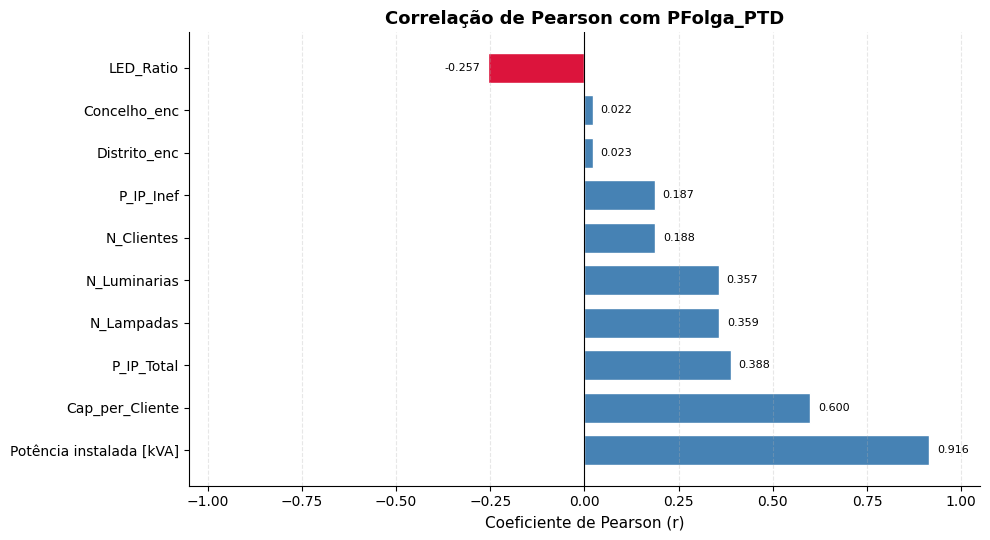

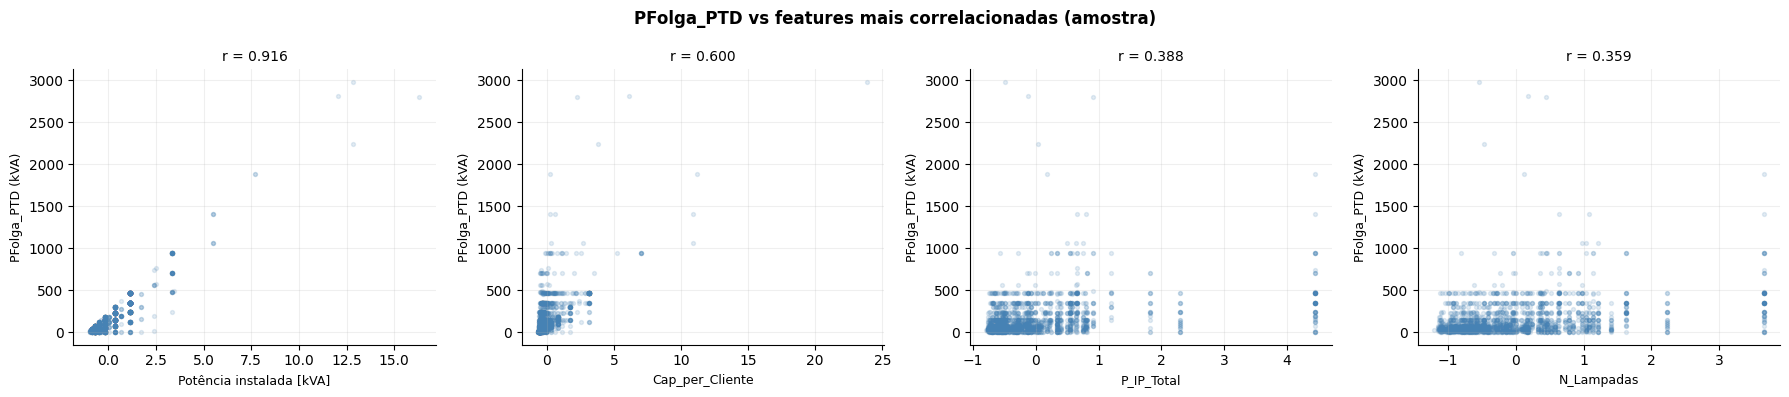


Correlação de Pearson com PFolga_PTD (ordenado por |r|):
  Feature                  r       Interpretação
  ──────────────────────── ─────── ─────────────
  Potência instalada [kVA] 0.9159  forte pos.   
  Cap_per_Cliente          0.5996  forte pos.   
  P_IP_Total               0.3884  moderada pos.
  N_Lampadas               0.3585  moderada pos.
  N_Luminarias             0.3575  moderada pos.
  LED_Ratio                -0.2573 moderada neg.
  N_Clientes               0.1880  fraca pos.   
  P_IP_Inef                0.1874  fraca pos.   
  Distrito_enc             0.0228  fraca pos.   
  Concelho_enc             0.0220  fraca pos.   


In [20]:
corr_pfolga = X_scaled.corrwith(y_reg).sort_values(ascending=False)

# Paleta: azul para positivo, vermelho para negativo
colors_bar = ['steelblue' if v >= 0 else 'crimson' for v in corr_pfolga.values]

fig, ax = plt.subplots(figsize=(10, 0.45 * len(corr_pfolga) + 1))
bars = ax.barh(corr_pfolga.index, corr_pfolga.values, color=colors_bar, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente de Pearson (r)', fontsize=11)
ax.set_title('Correlação de Pearson com PFolga_PTD', fontsize=13, fontweight='bold')
ax.set_xlim(-1.05, 1.05)
ax.grid(True, axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Anotar valores
for bar, val in zip(bars, corr_pfolga.values):
    ha = 'left' if val >= 0 else 'right'
    offset = 0.02 if val >= 0 else -0.02
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha=ha, fontsize=8)
plt.tight_layout()
plt.show()

top4 = corr_pfolga.abs().sort_values(ascending=False).head(4).index.tolist()
sample_idx = np.random.default_rng(CFG['random_state']).choice(len(X_scaled), size=min(CFG['sample_viz'], len(X_scaled)), replace=False)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('PFolga_PTD vs features mais correlacionadas (amostra)', fontsize=12, fontweight='bold')
for ax, feat in zip(axes, top4):
    r = corr_pfolga[feat]
    ax.scatter(X_scaled[feat].iloc[sample_idx], y_reg.iloc[sample_idx],
               alpha=0.15, s=8, color='steelblue' if r >= 0 else 'crimson')
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('PFolga_PTD (kVA)', fontsize=9)
    ax.set_title(f'r = {r:.3f}', fontsize=10)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("\nCorrelação de Pearson com PFolga_PTD (ordenado por |r|):")
print_table(
    headers=['Feature', 'r', 'Interpretação'],
    rows=[
        (f, f'{corr_pfolga[f]:.4f}',
         'forte pos.' if corr_pfolga[f] >= 0.5 else
         'moderada pos.' if corr_pfolga[f] >= 0.2 else
         'fraca pos.' if corr_pfolga[f] >= 0 else
         'forte neg.' if corr_pfolga[f] <= -0.5 else
         'moderada neg.' if corr_pfolga[f] <= -0.2 else 'fraca neg.')
        for f in corr_pfolga.abs().sort_values(ascending=False).index
    ],
)


### 4.2.2 - Regrassão linear simples (K-Fold Cross Validation)

In [21]:
# Calculamos a correlação de todas as features com PFolga_PTD e escolhemos
# a de maior correlação absoluta: garante escolha objetiva e justificável.

correlations = X_scaled.corrwith(y_reg).abs().sort_values(ascending=False)
best_feature  = correlations.index[0]
best_corr     = correlations.iloc[0]

print(f"\nTop 5 correlações com PFolga_PTD:")
for feat, corr in correlations.head(5).items():
    marker = " foi selecionada" if feat == best_feature else ""
    print(f"  {feat:<35} r = {corr:.4f}{marker}")

print(f"{best_feature} tem a correlação linear mais forte com PFolga_PTD (|r| = {best_corr:.4f}), sendo a variável com maior poder explicativo individual para a regressão linear simples.")


Top 5 correlações com PFolga_PTD:
  Potência instalada [kVA]            r = 0.9159 foi selecionada
  Cap_per_Cliente                     r = 0.5996
  P_IP_Total                          r = 0.3884
  N_Lampadas                          r = 0.3585
  N_Luminarias                        r = 0.3575
Potência instalada [kVA] tem a correlação linear mais forte com PFolga_PTD (|r| = 0.9159), sendo a variável com maior poder explicativo individual para a regressão linear simples.


In [22]:
X_simple = X_scaled[[best_feature]]
y = y_reg.values

kf = KFold(n_splits=CFG['kfold_splits'])

mae_scores, rmse_scores = [], []
coefs, intercepts = [], []
y_real_all, y_pred_all = [], []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_simple), 1):
    X_train, X_test = X_simple.iloc[train_idx], X_simple.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae_scores.append(mean_absolute_error(y_test, y_pred))
    rmse_scores.append(root_mean_squared_error(y_test, y_pred))
    coefs.append(model.coef_[0])
    intercepts.append(model.intercept_)
    y_real_all.extend(y_test)
    y_pred_all.extend(y_pred)

# Modelo final: média dos coeficientes dos 5 folds
mean_coef = np.mean(coefs)
mean_intercept = np.mean(intercepts)
mean_mae = np.mean(mae_scores)
mean_rmse = np.mean(rmse_scores)
std_mae = np.std(mae_scores)
std_rmse = np.std(rmse_scores)

In [23]:
# Função linear resultante
print(f"\nPFolga_PTD = {mean_coef:.4f} * {best_feature} + {mean_intercept:.4f}")
print(f"\t(coeficientes: média dos 5 folds do K-Fold CV)")
print(f"\nInterpretação: por cada unidade de aumento em {best_feature}")
print(f"\t(escala standardizada), PFolga_PTD varia {mean_coef:.4f} kVA.")


PFolga_PTD = 171.0317 * Potência instalada [kVA] + 147.9805
	(coeficientes: média dos 5 folds do K-Fold CV)

Interpretação: por cada unidade de aumento em Potência instalada [kVA]
	(escala standardizada), PFolga_PTD varia 171.0317 kVA.


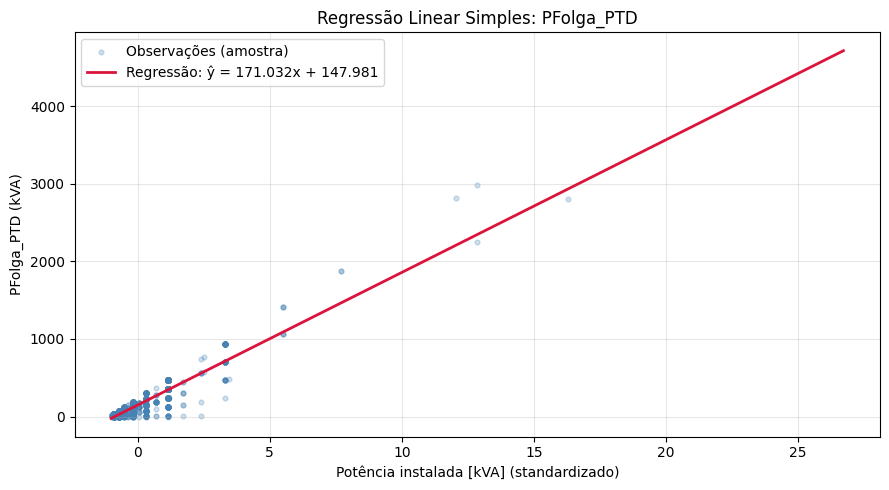

In [24]:
# Diagrama de dispersão e reta de regressão

# Amostra para visualização (72k pontos saturaria o gráfico)
sample_n  = CFG['sample_viz']
rng       = np.random.default_rng(CFG['random_state'])
sample_idk = np.random.default_rng(CFG['random_state']).choice(len(X_scaled), size=min(CFG['sample_viz'], len(X_scaled)), replace=False)
#sample_idx = rng.choice(len(y_real_all), size=sample_n, replace=False)

x_sample  = np.array(X_simple[best_feature])[sample_idx] \
            if len(y_real_all) == len(X_simple) \
            else np.array(X_simple[best_feature].values)[sample_idx]

y_sample  = np.array(y_real_all)[sample_idx]

x_line    = np.linspace(X_simple[best_feature].min(), X_simple[best_feature].max(), 300)
y_line    = mean_coef * x_line + mean_intercept

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x_sample, y_sample, alpha=0.25, s=12, color='steelblue', label='Observações (amostra)')
ax.plot(x_line, y_line, color='crimson', linewidth=2,
        label=f'Regressão: ŷ = {mean_coef:.3f}x + {mean_intercept:.3f}')
ax.set_xlabel(f'{best_feature} (standardizado)')
ax.set_ylabel('PFolga_PTD (kVA)')
ax.set_title('Regressão Linear Simples: PFolga_PTD')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
rows = [
    [i, mae, rmse]
    for i, (mae, rmse) in enumerate(zip(mae_scores, rmse_scores), 1)
]

rows += [
    ["Média", mean_mae, mean_rmse],
    ["Std", std_mae, std_rmse],
]

print_table(
    headers=["Fold", "MAE", "RMSE"],
    rows=rows,
    title="MAE e RMSE"
)


MAE e RMSE
  Fold      MAE    RMSE
  ───── ─────── ───────
  1     50.8160 74.9137
  2     50.7118 74.7994
  3     50.7248 75.2383
  Média 50.7508 74.9838
  Std    0.0463  0.1859


### 4.2.3 - Modelos de regressão (K-Fold Cross Validation)

In [26]:
kf = KFold(n_splits=CFG['kfold_splits'], shuffle=True, random_state=CFG['random_state'])

# corre CV e devolve métricas + previsões concatenadas
def run_cv(model, X, y, kf):
    mae_scores, rmse_scores = [], []
    y_real_all, y_pred_all  = [], []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        rmse_scores.append(root_mean_squared_error(y_test, y_pred))
        y_real_all.extend(y_test)
        y_pred_all.extend(y_pred)

    return {
        'mae_mean': np.mean(mae_scores), 'mae_std': np.std(mae_scores),
        'rmse_mean': np.mean(rmse_scores), 'rmse_std': np.std(rmse_scores),
        'y_real': np.array(y_real_all), 'y_pred': np.array(y_pred_all),
        'mae_folds': mae_scores, 'rmse_folds': rmse_scores
    }

X = X_reg_scaled
y = y_reg.values
results_all = {}

In [27]:
# Regressão linear múltipla

model_lr = LinearRegression()
res_lr   = run_cv(model_lr, X, y, kf)
results_all['Linear'] = res_lr

# Treinar no dataset completo para obter coeficientes finais
model_lr.fit(X, y)
coef_df = pd.DataFrame({
    'Feature':     selected_features_reg,
    'Coeficiente': model_lr.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print(f"\nTop 10 coeficientes (valor absoluto):")
print(coef_df.head(10).to_string(index=False))

print(f"\nIntercepto: {model_lr.intercept_:.4f}")
print(f"\nMAE  = {res_lr['mae_mean']:.4f} +/- {res_lr['mae_std']:.4f}")
print(f"RMSE = {res_lr['rmse_mean']:.4f} +/- {res_lr['rmse_std']:.4f}")


Top 10 coeficientes (valor absoluto):
                 Feature  Coeficiente
              N_Lampadas  -251.328112
            N_Luminarias   237.573447
Potência instalada [kVA]   196.877626
              N_Clientes   -53.704141
              P_IP_Total    14.304770
               P_IP_Inef    -5.195123
            Concelho_enc     0.945135
         Cap_per_Cliente    -0.567904
            Distrito_enc    -0.556864
               LED_Ratio     0.404756

Intercepto: 147.9833

MAE  = 37.5241 +/- 0.2943
RMSE = 57.4133 +/- 0.8076



  MAE  = 36.3807 +/- 0.2662
  RMSE = 60.0568 +/- 1.6220


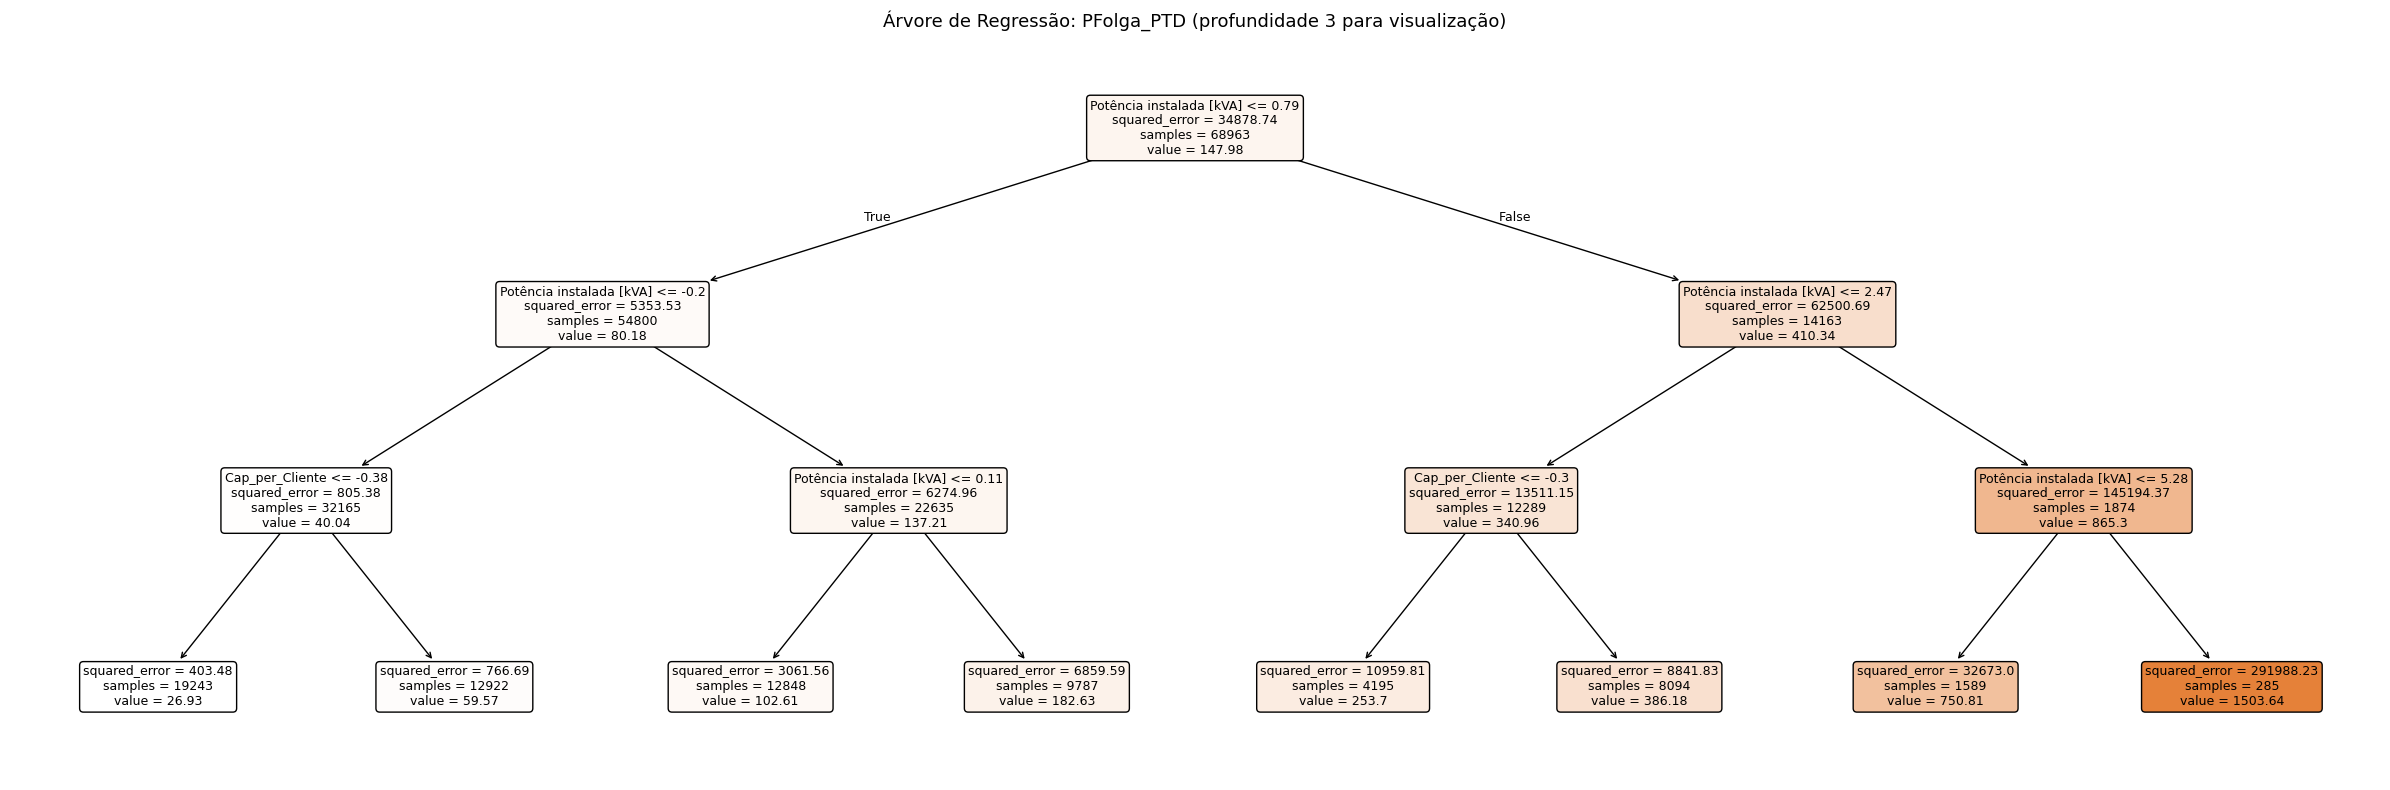

Nota: árvore visualizada com max_depth=3 para legibilidade;
modelo treinado com max_depth=10.


In [28]:
# Árvore de regressão

model_tree = DecisionTreeRegressor(max_depth=CFG["tree_max_depth"], random_state=CFG["random_state"])
res_tree   = run_cv(model_tree, X, y, kf)
results_all['Tree'] = res_tree

print(f"\n  MAE  = {res_tree['mae_mean']:.4f} +/- {res_tree['mae_std']:.4f}")
print(f"  RMSE = {res_tree['rmse_mean']:.4f} +/- {res_tree['rmse_std']:.4f}")

# Visualização da árvore (max_depth=3 para legibilidade)
model_tree_viz = DecisionTreeRegressor(max_depth=CFG["tree_viz_depth"], random_state=CFG["random_state"])
model_tree_viz.fit(X, y)

fig, ax = plt.subplots(figsize=(24, 8))
plot_tree(
    model_tree_viz, feature_names=selected_features_reg,
    filled=True, rounded=True, fontsize=9, ax=ax,
    impurity=True, precision=2
)
ax.set_title('Árvore de Regressão: PFolga_PTD (profundidade 3 para visualização)', fontsize=13)
plt.tight_layout()
plt.show()
print(f"Nota: árvore visualizada com max_depth={CFG["tree_viz_depth"]} para legibilidade;")
print("modelo treinado com max_depth=10.")

In [29]:
# Optimização do kernel
# LinearSVR é O(n) vs SVR RBF que é O(n²)
# Testamos diferentes valores de C (regularização) como otimização.
svm_results = []
for c in CFG['svm_configs']:
      m = LinearSVR(C=c['C'], max_iter=CFG["svm_max_iter"], random_state=CFG["random_state"],
              dual=True)
      res = run_cv(m, X, y, kf)
      svm_results.append({**c, **res})
      print(f"  {c['name']:<22} MAE={res['mae_mean']:.4f}+/-{res['mae_std']:.4f}  "
          f"RMSE={res['rmse_mean']:.4f}+/-{res['rmse_std']:.4f}")

best_svm     = min(svm_results, key=lambda r: r['mae_mean'])
results_all['SVM'] = best_svm
print(f"\nMelhor configuração SVM: {best_svm['name']} "
      f"(MAE={best_svm['mae_mean']:.4f})")

  LinearSVR C=0.1        MAE=37.0937+/-0.0800  RMSE=59.8852+/-0.5619
  LinearSVR C=1.0        MAE=36.7400+/-0.1841  RMSE=59.4509+/-0.9681
  LinearSVR C=10         MAE=36.7257+/-0.1978  RMSE=59.4584+/-1.0699

Melhor configuração SVM: LinearSVR C=10 (MAE=36.7257)


/usr/local/lib/python3.14/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.14/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.14/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.14/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(



  Rasa (1 camada, sem reg.)
	Arquitetura: (64,)  L2=0.0001  lr=0.001
	MAE  = 92.5781 +/- 1.4185
	RMSE = 156.5062 +/- 10.1833


/usr/local/lib/python3.14/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.14/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.14/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.14/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(



  Média (2 camadas, L2 moderado)
	Arquitetura: (128, 64)  L2=0.001  lr=0.001
	MAE  = 38.0790 +/- 0.9333
	RMSE = 59.6930 +/- 3.6361


/usr/local/lib/python3.14/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.14/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.14/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(



  Profunda (3 camadas, L2 forte)
	Arquitetura: (256, 128, 64)  L2=0.01  lr=0.001
	MAE  = 38.6002 +/- 1.0701
	RMSE = 59.8663 +/- 2.5458

Melhor configuração NN: Média (2 camadas, L2 moderado) (MAE=38.0790)


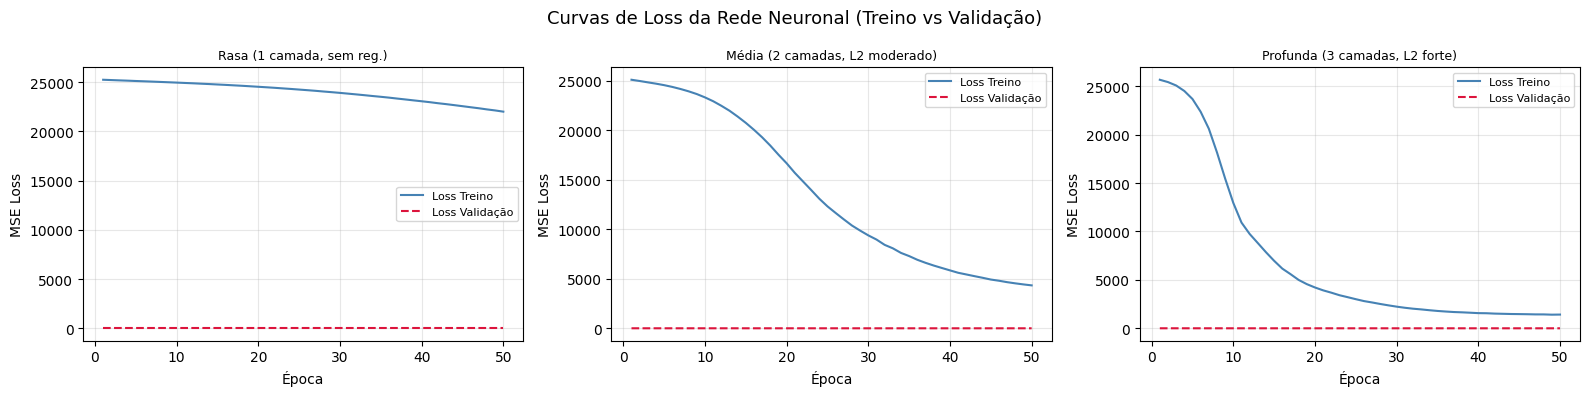

In [30]:
# Subsample para CV
sample_idx_cv = np.random.default_rng(CFG['random_state']).choice(len(X), size=CFG['sample_cv'], replace=False)
X_cv = X.iloc[sample_idx_cv]
y_cv = y[sample_idx_cv]

# Subsample separado para curvas de loss
sample_idx_loss = np.random.default_rng(CFG['random_state']).choice(len(X), size=CFG['sample_loss'], replace=False)
X_loss = X.iloc[sample_idx_loss]
y_loss = y[sample_idx_loss]

nn_results  = []
loss_curves = []

for c in CFG['nn_configs']:
    m = MLPRegressor(
        hidden_layer_sizes  = c['hidden_layer_sizes'],
        alpha               = c['alpha'],
        learning_rate_init  = c['learning_rate_init'],
        max_iter            = CFG['nn_max_iter'],
        early_stopping      = CFG['nn_early_stopping'],
        validation_fraction = CFG['nn_validation_fraction'],
        n_iter_no_change    = CFG['nn_n_iter_no_change'],
        random_state        = CFG['random_state'],
    )

    res = run_cv(m, X_cv, y_cv, kf)
    nn_results.append({**c, **res})

    m_full = MLPRegressor(
        hidden_layer_sizes  = c['hidden_layer_sizes'],
        alpha               = c['alpha'],
        learning_rate_init  = c['learning_rate_init'],
        max_iter            = CFG['nn_max_iter'],
        early_stopping      = CFG['nn_early_stopping'],
        validation_fraction = CFG['nn_validation_fraction'],
        n_iter_no_change    = CFG['nn_n_iter_no_change'],
        random_state        = CFG['random_state'],
    )
    m_full.fit(X_loss, y_loss)

    loss_curves.append({
        'name':       c['name'],
        'train_loss': m_full.loss_curve_,
        'val_loss':   m_full.validation_scores_,
    })

    print(f"\n  {c['name']}")
    print(f"\tArquitetura: {c['hidden_layer_sizes']}  L2={c['alpha']}  lr={c['learning_rate_init']}")
    print(f"\tMAE  = {res['mae_mean']:.4f} +/- {res['mae_std']:.4f}")
    print(f"\tRMSE = {res['rmse_mean']:.4f} +/- {res['rmse_std']:.4f}")

best_nn = min(nn_results, key=lambda r: r['mae_mean'])
results_all['NeuralNet'] = best_nn
print(f"\nMelhor configuração NN: {best_nn['name']} (MAE={best_nn['mae_mean']:.4f})")

# Curvas de loss
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Curvas de Loss da Rede Neuronal (Treino vs Validação)', fontsize=13)
for ax, lc in zip(axes, loss_curves):
    epochs     = range(1, len(lc['train_loss']) + 1)
    val_epochs = range(1, len(lc['val_loss']) + 1)
    ax.plot(epochs,     lc['train_loss'],              label='Loss Treino',    color='steelblue')
    ax.plot(val_epochs, [-v for v in lc['val_loss']], label='Loss Validação', color='crimson', linestyle='--')
    ax.set_title(lc['name'], fontsize=9)
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2.4 - Comparação de modelos

In [31]:
rows = [
    [
        name,
        res["mae_mean"],
        res["mae_std"],
        res["rmse_mean"],
        res["rmse_std"],
    ]
    for name, res in results_all.items()
]

print_table(
    headers=["Modelo", "MAE", "+/-", "RMSE", "+/-"],
    rows=rows,
    title="Comparação de Modelos"
)

best_model_name = min(results_all, key=lambda k: results_all[k]["mae_mean"])

print(
    f"\nMelhor modelo: {best_model_name} "
    f"(MAE={results_all[best_model_name]['mae_mean']:.4f})"
)

# Guardar para depois
best_models = sorted(results_all, key=lambda k: results_all[k]["mae_mean"])
print(f"Ranking: {best_models}")


Comparação de Modelos
  Modelo        MAE    +/-    RMSE    +/-
  ───────── ─────── ────── ─────── ──────
  Linear    37.5241 0.2943 57.4133 0.8076
  Tree      36.3807 0.2662 60.0568 1.6220
  SVM       36.7257 0.1978 59.4584 1.0699
  NeuralNet 38.0790 0.9333 59.6930 3.6361

Melhor modelo: Tree (MAE=36.3807)
Ranking: ['Tree', 'SVM', 'Linear', 'NeuralNet']


### 4.2.5 - Curvas de aprendizagem (2 Melhores Modelos)

In [32]:
best_models_reg = sorted(results_all, key=lambda k: results_all[k]['mae_mean'])[:2]
print(f"\n\t2 melhores modelos: {best_models_reg}")

def make_reg_model(name):
    if name == 'Linear':
        return LinearRegression()
    elif name == 'Tree':
        return DecisionTreeRegressor(max_depth=CFG['tree_max_depth'], random_state=CFG['random_state'])
    elif name == 'SVM':
        return LinearSVR(C=best_svm['C'], max_iter=CFG['svm_max_iter'], random_state=CFG['random_state'])
    elif name == 'NeuralNet':
        return MLPRegressor(
            hidden_layer_sizes  = best_nn['hidden_layer_sizes'],
            alpha               = best_nn['alpha'],
            learning_rate_init  = best_nn['learning_rate_init'],
            max_iter            = CFG['nn_max_iter'],
            early_stopping      = CFG['nn_early_stopping'],
            n_iter_no_change    = CFG['nn_n_iter_no_change'],
            random_state        = CFG['random_state'],
        )

# Subsample para learning_curve ser viável (mantém distribuição)
sample_idx = np.random.default_rng(CFG['random_state']).choice(len(X), size=CFG['sample_cv'], replace=False)
X_lc = X.iloc[sample_idx]
y_lc = y[sample_idx]


	2 melhores modelos: ['Tree', 'SVM']


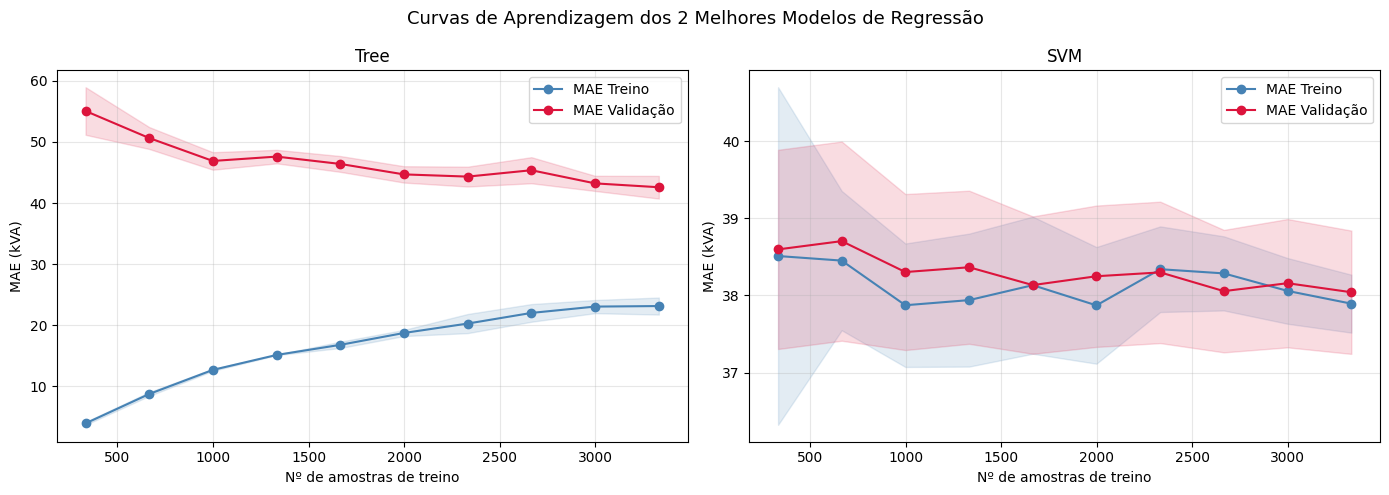

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Aprendizagem dos 2 Melhores Modelos de Regressão', fontsize=13)

diagnostics = {}

for idx, model_name in enumerate(best_models_reg):
    model = make_reg_model(model_name)

    train_sizes, train_scores, val_scores = learning_curve(
        model, X_lc, y_lc,
        cv          = CFG['kfold_splits'],
        train_sizes = np.linspace(0.1, 1.0, 10),
        scoring     = 'neg_mean_absolute_error',
        n_jobs      = -1,
    )

    # Converter de negativo para positivo (MAE)
    train_mae = -train_scores
    val_mae   = -val_scores

    train_mean = train_mae.mean(axis=1)
    train_std  = train_mae.std(axis=1)
    val_mean   = val_mae.mean(axis=1)
    val_std    = val_mae.std(axis=1)

    ax = axes[idx]
    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='MAE Treino')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='steelblue')
    ax.plot(train_sizes, val_mean, 'o-', color='crimson', label='MAE Validação')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='crimson')
    ax.set_xlabel('Nº de amostras de treino')
    ax.set_ylabel('MAE (kVA)')
    ax.set_title(f'{model_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Diagnóstico automático
    final_train = train_mean[-1]
    final_val   = val_mean[-1]
    gap         = final_val - final_train   # positivo = val pior que treino

    diagnostics[model_name] = {
        'final_train': final_train,
        'final_val':   final_val,
        'gap':         gap,
    }

plt.tight_layout()
plt.show()

In [34]:
# Intepretação automatica

for model_name, d in diagnostics.items():
    print(f"\n  {model_name}:")
    print(f"\tMAE Treino   (final): {d['final_train']:.4f} kVA")
    print(f"\tMAE Validação (final): {d['final_val']:.4f} kVA")
    print(f"\tGap (val - treino):   {d['gap']:.4f} kVA")

    if d['gap'] > 20 and d['final_train'] < 10:
        diagnosis = "! OVERFITTING: treino muito melhor que validação"
        detail    = "O modelo memoriza os dados de treino mas não generaliza."
    elif d['final_val'] > 60:
        diagnosis = "! UNDERFITTING: erro elevado em treino e validação"
        detail    = "O modelo não tem capacidade suficiente para capturar o padrão."
    elif d['gap'] < 10:
        diagnosis = ". TREINO ADEQUADO: curvas convergem e gap reduzido"
        detail    = "O modelo generaliza bem para dados não vistos."
    else:
        diagnosis = "~ LIGEIRO OVERFITTING: gap moderado, aceitável"
        detail    = "Considerar mais regularização ou menos profundidade."

    # Guardar no dicionário para usar no report
    d['diagnosis'] = diagnosis
    d['detail']    = detail

    print(f"    {diagnosis}")
    print(f"\t{detail}")


  Tree:
	MAE Treino   (final): 23.1522 kVA
	MAE Validação (final): 42.5872 kVA
	Gap (val - treino):   19.4351 kVA
    ~ LIGEIRO OVERFITTING: gap moderado, aceitável
	Considerar mais regularização ou menos profundidade.

  SVM:
	MAE Treino   (final): 37.8922 kVA
	MAE Validação (final): 38.0402 kVA
	Gap (val - treino):   0.1480 kVA
    . TREINO ADEQUADO: curvas convergem e gap reduzido
	O modelo generaliza bem para dados não vistos.


As curvas de aprendizagem avaliam se os modelos beneficiariam
de mais dados (curvas ainda a convergir) ou se já estabilizaram.
Um gap persistente entre treino e validação indica overfitting;
curvas altas e paralelas indicam underfitting. A estabilização
das curvas com o aumento de amostras sugere que mais dados não
melhorariam significativamente o desempenho.

### 4.2.6 - Testes de significancia estatistica

In [35]:
# Erro dos dois melhores modelos
best_models_reg = sorted(results_all, key=lambda k: results_all[k]['mae_mean'])[:2]
m1_name, m2_name = best_models_reg

print(f"\n  Modelos comparados: {m1_name} vs {m2_name}")

if CFG['sample_cv']:
    idx  = np.random.default_rng(CFG['random_state']).choice(len(X), size=CFG['sample_cv'], replace=False)
    X_cv = X.iloc[idx]
    y_cv = y[idx]
else:
    X_cv, y_cv = X, y

kf = KFold(n_splits=CFG['kfold_splits'], shuffle=True, random_state=CFG['random_state'])
errors_m1, errors_m2 = [], []

for train_idx, test_idx in kf.split(X_cv):
    X_train, X_test = X_cv.iloc[train_idx], X_cv.iloc[test_idx]
    y_train, y_test = y_cv[train_idx],      y_cv[test_idx]

    for name, errors_list in [(m1_name, errors_m1), (m2_name, errors_m2)]:
        m = make_reg_model(name)
        m.fit(X_train, y_train)
        errors_list.append(np.abs(y_test - m.predict(X_test)))

errors_m1 = np.concatenate(errors_m1)
errors_m2 = np.concatenate(errors_m2)



  Modelos comparados: Tree vs SVM


In [36]:
# TESTE DE NORMALIDADE (Shapiro-Wilk, max 5000 amostras)

n_shapiro  = min(5000, len(errors_m1))
rng        = np.random.default_rng(CFG['random_state'])
sample_idx = rng.choice(len(errors_m1), size=n_shapiro, replace=False)

_, p_m1 = shapiro(errors_m1[sample_idx])
_, p_m2 = shapiro(errors_m2[sample_idx])

normal_m1 = p_m1 > 0.05
normal_m2 = p_m2 > 0.05

print(f"\n  {m1_name:<12}: p = {p_m1:.4f}: {'Normal' if normal_m1 else 'Não-normal'}")
print(f"  {m2_name:<12}: p = {p_m2:.4f}: {'Normal' if normal_m2 else 'Não-normal'}")


  Tree        : p = 0.0000: Não-normal
  SVM         : p = 0.0000: Não-normal


In [37]:

# Paramétrico (t-test pareado) se ambos normais, senão Wilcoxon
if normal_m1 and normal_m2:
    stat, p_val   = ttest_rel(errors_m1, errors_m2)
    test_name     = "t-test Pareado"
    justification = "Ambas as distribuições são normais: teste paramétrico adequado."
else:
    stat, p_val   = wilcoxon(errors_m1, errors_m2)
    test_name     = "Wilcoxon Signed-Rank"
    justification = ("Pelo menos uma distribuição não é normal: teste não-paramétrico.\n"
                     "\tWilcoxon é mais robusto que Mann-Whitney para erros pareados.")

print(f"Teste de diferença {test_name} (α = 0.05)")
print(f"\n\{justification}")
print(f"\n\tEstatística : {stat:.4f}")
print(f"\tp-value     : {p_val:.4f}")

significativo = p_val < 0.05
print(f"\n\tResultado   : {'Diferença SIGNIFICATIVA' if significativo else 'Sem diferença significativa'} (α = 0.05)")

Teste de diferença Wilcoxon Signed-Rank (α = 0.05)

\Pelo menos uma distribuição não é normal: teste não-paramétrico.
	Wilcoxon é mais robusto que Mann-Whitney para erros pareados.

	Estatística : 5849948.5000
	p-value     : 0.0001

	Resultado   : Diferença SIGNIFICATIVA (α = 0.05)


In [38]:
mae_m1 = results_all[m1_name]['mae_mean']
mae_m2 = results_all[m2_name]['mae_mean']
melhor = m1_name if mae_m1 < mae_m2 else m2_name

print(f"""
\t{m1_name:<12}: MAE = {mae_m1:.4f} +/- {results_all[m1_name]['mae_std']:.4f}
\t{m2_name:<12}: MAE = {mae_m2:.4f} +/- {results_all[m2_name]['mae_std']:.4f}
""")

if significativo:
    print(f"A diferença entre {m1_name} e {m2_name} é estatisticamente")
    print(f"significativa (p={p_val:.4f} < 0.05). O modelo com melhor")
    print(f"desempenho é {melhor} (menor MAE).")
else:
    print(f"A diferença entre {m1_name} e {m2_name} NÃO é estatisticamente")
    print(f"significativa (p={p_val:.4f} ≥ 0.05). Ambos os modelos têm")
    print(f"desempenho equivalente: {melhor} tem MAE ligeiramente inferior")
    print(f"mas a diferença pode ser devida ao acaso.")

print(f"\nMelhor modelo: {melhor}")
best_reg_model = melhor


	Tree        : MAE = 36.3807 +/- 0.2662
	SVM         : MAE = 36.7257 +/- 0.1978

A diferença entre Tree e SVM é estatisticamente
significativa (p=0.0001 < 0.05). O modelo com melhor
desempenho é Tree (menor MAE).

Melhor modelo: Tree


## 4.3. Classificação

### 4.3.1 - Modelos de classificação (K-Fold Cross Validation)

In [39]:
kf = KFold(n_splits=CFG['kfold_splits'], shuffle=True, random_state=CFG['random_state'])

# Subsampling para modelos lentos
if CFG['sample_cv']:
    idx  = np.random.default_rng(CFG['random_state']).choice(len(X_clf_scaled), size=CFG['sample_cv'], replace=False)
    X_cv = X_clf_scaled.iloc[idx]
    y_cv = y_clf_encoded[idx]
else:
    X_cv = X_clf_scaled
    y_cv = y_clf_encoded

class_names = le_utiliz.classes_   # ['alto', 'baixo', 'medio']
results_clf = {}

# corre CV e devolve métricas por fold e médias
def run_cv_clf(model, X, y, kf, class_names):
    acc, prec, rec, f1 = [], [], [], []
    y_real_all, y_pred_all = [], []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx],      y[test_idx]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc.append(accuracy_score(y_test, y_pred))
        prec.append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
        rec.append(recall_score(y_test, y_pred,  average='weighted', zero_division=0))
        f1.append(f1_score(y_test, y_pred,    average='weighted', zero_division=0))
        y_real_all.extend(y_test)
        y_pred_all.extend(y_pred)

    return {
        'Accuracy_mean':  np.mean(acc),  'Accuracy_std':  np.std(acc),
        'Precision_mean': np.mean(prec), 'Precision_std': np.std(prec),
        'Recall_mean':    np.mean(rec),  'Recall_std':    np.std(rec),
        'F1_mean':        np.mean(f1),   'F1_std':        np.std(f1),
        'y_real': np.array(y_real_all),
        'y_pred': np.array(y_pred_all),
    }

def print_clf_results(name, res):
    print(f"\n  {name}:")
    print(f"\t{'Accuracy' :<12} = {res['Accuracy_mean'] :.4f} +/- {res['Accuracy_std'] :.4f}")
    print(f"\t{'Precision':<12} = {res['Precision_mean']:.4f} +/- {res['Precision_std']:.4f}")
    print(f"\t{'Recall'   :<12} = {res['Recall_mean']   :.4f} +/- {res['Recall_std']   :.4f}")
    print(f"\t{'F1-Score' :<12} = {res['F1_mean']       :.4f} +/- {res['F1_std']       :.4f}")


  Decision_Tree:
	Accuracy     = 0.5828 +/- 0.0159
	Precision    = 0.5794 +/- 0.0149
	Recall       = 0.5828 +/- 0.0159
	F1-Score     = 0.5798 +/- 0.0158


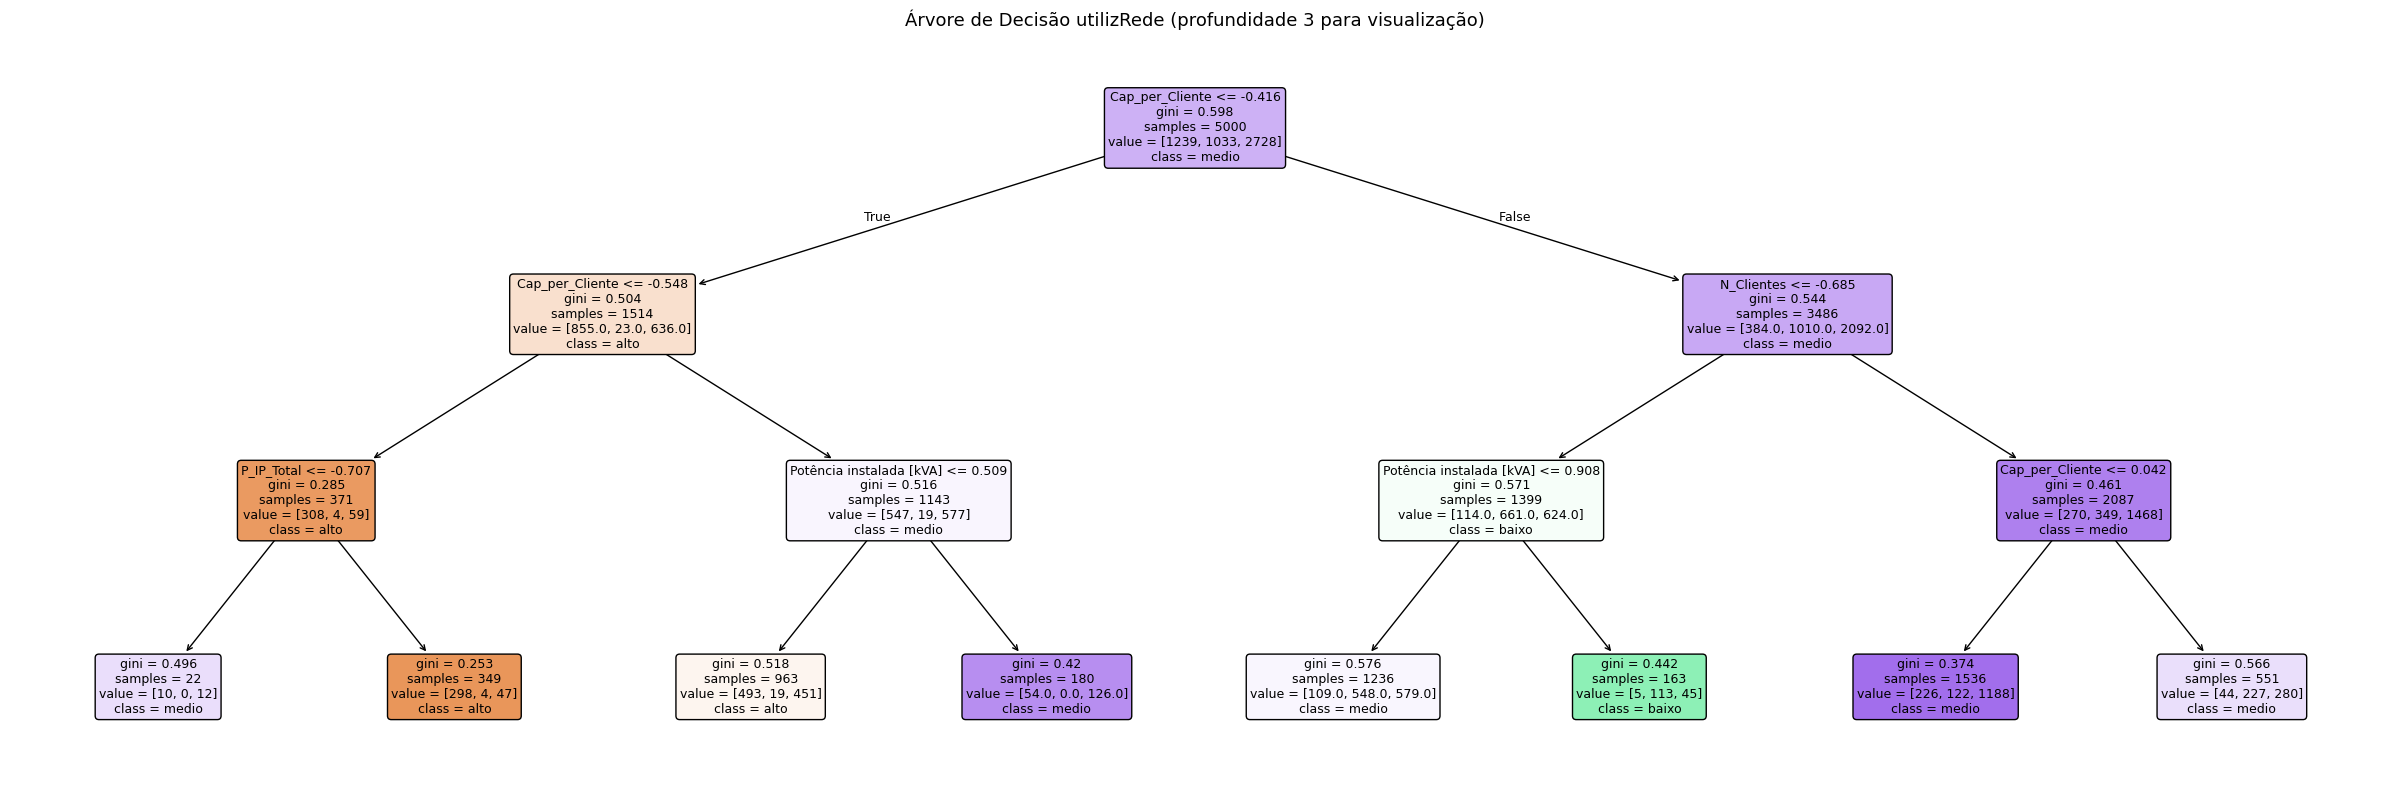

Nota: árvore visualizada com max_depth=3; modelo treinado com max_depth=10.


In [40]:
# Arvore de decisão para classificação (max_depth=10 para evitar overfitting)

model_tree_clf = DecisionTreeClassifier(max_depth=CFG["tree_max_depth"], random_state=CFG['random_state'])
res_tree_clf   = run_cv_clf(model_tree_clf, X_cv, y_cv, kf, class_names)
results_clf['Decision_Tree'] = res_tree_clf
print_clf_results('Decision_Tree', res_tree_clf)

# Visualização (depth=3 para legibilidade)
model_tree_viz = DecisionTreeClassifier(max_depth=CFG["tree_viz_depth"], random_state=CFG['random_state'])
model_tree_viz.fit(X_cv, y_cv)
fig, ax = plt.subplots(figsize=(24, 8))
plot_tree(model_tree_viz, feature_names=selected_features_clf,
          class_names=class_names, filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title('Árvore de Decisão utilizRede (profundidade 3 para visualização)', fontsize=13)
plt.tight_layout()
plt.show()
print(f"Nota: árvore visualizada com max_depth={CFG['tree_viz_depth']}; modelo treinado com max_depth={CFG['tree_max_depth']}.")

In [41]:
# Rede Neuronal para classificação
if CFG['sample_loss']:
    idx_loss = np.random.default_rng(0).choice(len(X_clf_scaled), size=CFG['sample_loss'], replace=False)
    X_loss   = X_clf_scaled.iloc[idx_loss]
    y_loss   = y_clf_encoded[idx_loss]
else:
    X_loss, y_loss = X_clf_scaled, y_clf_encoded

nn_clf_results = []
loss_curves_clf = []

for cfg in CFG['nn_configs']:
    m = MLPClassifier(
        hidden_layer_sizes  = cfg['hidden_layer_sizes'],
        alpha               = cfg['alpha'],
        learning_rate_init  = cfg['learning_rate_init'],
        max_iter            = CFG['nn_max_iter'],
        early_stopping      = CFG['nn_early_stopping'],
        validation_fraction = CFG['nn_validation_fraction'],
        n_iter_no_change    = CFG['nn_n_iter_no_change'],
        random_state        = CFG['random_state'],
    )
    res = run_cv_clf(m, X_cv, y_cv, kf, class_names)
    nn_clf_results.append({**cfg, **res})
    print_clf_results(cfg['name'], res)

    # Curvas de loss
    m_full = MLPClassifier(
        hidden_layer_sizes  = cfg['hidden_layer_sizes'],
        alpha               = cfg['alpha'],
        learning_rate_init  = cfg['learning_rate_init'],
        max_iter            = CFG['nn_max_iter'],
        early_stopping      = True,
        validation_fraction = CFG['nn_validation_fraction'],
        n_iter_no_change    = CFG['nn_n_iter_no_change'],
        random_state        = CFG['random_state'],
    )
    m_full.fit(X_loss, y_loss)
    loss_curves_clf.append({
        'name':       cfg['name'],
        'train_loss': m_full.loss_curve_,
        'val_loss':   m_full.validation_scores_,
    })

best_nn_clf = max(nn_clf_results, key=lambda r: r['F1_mean'])
results_clf['NeuralNet'] = best_nn_clf
print(f"\nMelhor configuração NN: {best_nn_clf['name']} (F1={best_nn_clf['F1_mean']:.4f})")


/usr/local/lib/python3.14/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(



  Rasa (1 camada, sem reg.):
	Accuracy     = 0.6270 +/- 0.0075
	Precision    = 0.6283 +/- 0.0085
	Recall       = 0.6270 +/- 0.0075
	F1-Score     = 0.6000 +/- 0.0032


/usr/local/lib/python3.14/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(



  Média (2 camadas, L2 moderado):
	Accuracy     = 0.6268 +/- 0.0171
	Precision    = 0.6232 +/- 0.0145
	Recall       = 0.6268 +/- 0.0171
	F1-Score     = 0.6071 +/- 0.0221

  Profunda (3 camadas, L2 forte):
	Accuracy     = 0.6312 +/- 0.0107
	Precision    = 0.6287 +/- 0.0078
	Recall       = 0.6312 +/- 0.0107
	F1-Score     = 0.6120 +/- 0.0113

Melhor configuração NN: Profunda (3 camadas, L2 forte) (F1=0.6120)


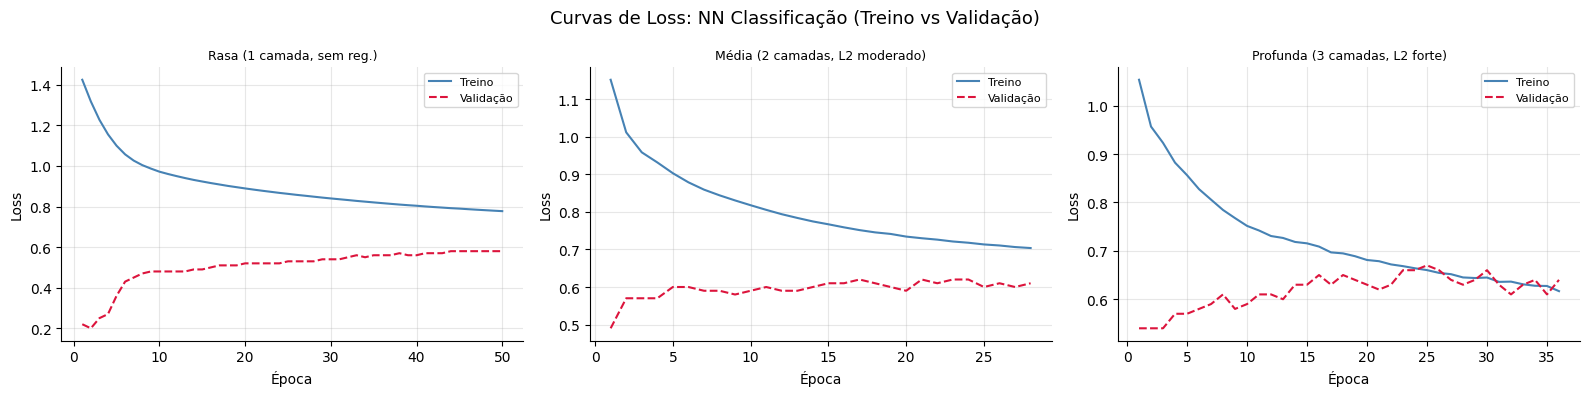

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Curvas de Loss: NN Classificação (Treino vs Validação)', fontsize=13)
for ax, lc in zip(axes, loss_curves_clf):
    epochs     = range(1, len(lc['train_loss']) + 1)
    val_epochs = range(1, len(lc['val_loss'])   + 1)
    ax.plot(epochs,     lc['train_loss'],              color='steelblue', label='Treino')
    ax.plot(val_epochs, lc['val_loss'],                color='crimson',   label='Validação', linestyle='--')
    ax.set_title(lc['name'], fontsize=9)
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [43]:
# Optimização do parametro C
svm_clf_configs = CFG['svm_configs']
svm_clf_results = []

for cfg in svm_clf_configs:
    m   = LinearSVC(C=cfg['C'], max_iter=CFG['svm_max_iter'], random_state=CFG['random_state'])
    res = run_cv_clf(m, X_cv, y_cv, kf, class_names)
    svm_clf_results.append({**cfg, **res})
    print(f"  {cfg['name']:<22} F1={res['F1_mean']:.4f}+/-{res['F1_std']:.4f}  "
          f"Acc={res['Accuracy_mean']:.4f}+/-{res['Accuracy_std']:.4f}")

best_svm_clf = max(svm_clf_results, key=lambda r: r['F1_mean'])
results_clf['SVM'] = best_svm_clf
print(f"\nMelhor SVM: {best_svm_clf['name']} (F1={best_svm_clf['F1_mean']:.4f})")

  LinearSVR C=0.1        F1=0.5164+/-0.0186  Acc=0.5914+/-0.0111
  LinearSVR C=1.0        F1=0.5171+/-0.0176  Acc=0.5916+/-0.0107
  LinearSVR C=10         F1=0.5170+/-0.0201  Acc=0.5914+/-0.0121

Melhor SVM: LinearSVR C=1.0 (F1=0.5171)


In [44]:
# Optimização do paramrtro K
knn_configs = [{'k': k} for k in [3, 5, 7, 11, 15]]
knn_results = []

for cfg in knn_configs:
    m   = KNeighborsClassifier(n_neighbors=cfg['k'], n_jobs=-1)
    res = run_cv_clf(m, X_cv, y_cv, kf, class_names)
    knn_results.append({**cfg, **res})
    print(f"  K={cfg['k']:<4} F1={res['F1_mean']:.4f}+/-{res['F1_std']:.4f}  "
          f"Acc={res['Accuracy_mean']:.4f}+/-{res['Accuracy_std']:.4f}")

best_knn = max(knn_results, key=lambda r: r['F1_mean'])
results_clf['KNN'] = best_knn
print(f"\nMelhor KNN: K={best_knn['k']} (F1={best_knn['F1_mean']:.4f})")

  K=3    F1=0.5391+/-0.0083  Acc=0.5426+/-0.0064
  K=5    F1=0.5514+/-0.0054  Acc=0.5552+/-0.0043
  K=7    F1=0.5573+/-0.0093  Acc=0.5662+/-0.0087
  K=11   F1=0.5641+/-0.0166  Acc=0.5808+/-0.0143
  K=15   F1=0.5584+/-0.0172  Acc=0.5838+/-0.0149

Melhor KNN: K=11 (F1=0.5641)


In [45]:
print(f"\n  {'Modelo':<15} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")

for name, res in results_clf.items():
    print(f"  {name:<15} {res['Accuracy_mean']:>10.4f} {res['Precision_mean']:>10.4f} "
          f"{res['Recall_mean']:>10.4f} {res['F1_mean']:>10.4f}")

best_clf_name = max(results_clf, key=lambda k: results_clf[k]['F1_mean'])
best_models_clf = sorted(results_clf, key=lambda k: results_clf[k]['F1_mean'], reverse=True)
print(f"\nMelhor modelo: {best_clf_name} (F1={results_clf[best_clf_name]['F1_mean']:.4f})")
print(f"\tRanking: {best_models_clf}")


  Modelo            Accuracy  Precision     Recall         F1
  Decision_Tree       0.5828     0.5794     0.5828     0.5798
  NeuralNet           0.6312     0.6287     0.6312     0.6120
  SVM                 0.5916     0.6295     0.5916     0.5171
  KNN                 0.5808     0.5701     0.5808     0.5641

Melhor modelo: NeuralNet (F1=0.6120)
	Ranking: ['NeuralNet', 'Decision_Tree', 'KNN', 'SVM']


### Métricas por classe

In [46]:
def metrics_per_class(model, X, y, kf, class_names):
    """Calcula média e std de Accuracy, Precision, Recall e F1 por classe."""
    # por classe: shape (n_folds, n_classes)
    prec_folds = {c: [] for c in class_names}
    rec_folds  = {c: [] for c in class_names}
    f1_folds   = {c: [] for c in class_names}
    acc_folds  = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx],      y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc_folds.append(accuracy_score(y_test, y_pred))

        p = precision_score(y_test, y_pred, average=None, labels=range(len(class_names)), zero_division=0)
        r = recall_score(   y_test, y_pred, average=None, labels=range(len(class_names)), zero_division=0)
        f = f1_score(       y_test, y_pred, average=None, labels=range(len(class_names)), zero_division=0)

        for i, c in enumerate(class_names):
            prec_folds[c].append(p[i])
            rec_folds[c].append(r[i])
            f1_folds[c].append(f[i])

    rows = []
    for c in class_names:
        rows.append({
            'Classe':       c,
            'Precision_mean': np.mean(prec_folds[c]), 'Precision_std': np.std(prec_folds[c]),
            'Recall_mean':    np.mean(rec_folds[c]),  'Recall_std':    np.std(rec_folds[c]),
            'F1_mean':        np.mean(f1_folds[c]),   'F1_std':        np.std(f1_folds[c]),
        })
    # Accuracy é global (não por classe)
    rows.append({
        'Classe':         'GLOBAL (weighted)',
        'Precision_mean': np.mean([np.mean(prec_folds[c]) for c in class_names]),
        'Precision_std':  np.mean([np.std(prec_folds[c])  for c in class_names]),
        'Recall_mean':    np.mean([np.mean(rec_folds[c])  for c in class_names]),
        'Recall_std':     np.mean([np.std(rec_folds[c])   for c in class_names]),
        'F1_mean':        np.mean([np.mean(f1_folds[c])   for c in class_names]),
        'F1_std':         np.mean([np.std(f1_folds[c])    for c in class_names]),
    })
    return pd.DataFrame(rows), np.mean(acc_folds), np.std(acc_folds)


def make_clf_model_full(name):
    """Recria o melhor modelo de cada tipo para métricas por classe."""
    if name == 'Decision_Tree':
        return DecisionTreeClassifier(max_depth=10, random_state=CFG['random_state'])
    elif name == 'NeuralNet':
        return MLPClassifier(
            hidden_layer_sizes  = best_nn_clf['hidden_layer_sizes'],
            alpha               = best_nn_clf['alpha'],
            learning_rate_init  = best_nn_clf['learning_rate_init'],
            max_iter            = CFG['nn_max_iter'],
            early_stopping      = CFG['nn_early_stopping'],
            validation_fraction = CFG['nn_validation_fraction'],
            n_iter_no_change    = CFG['nn_n_iter_no_change'],
            random_state        = CFG['random_state'],
        )
    elif name == 'SVM':
        return LinearSVC(C=best_svm_clf['C'], max_iter=CFG['svm_max_iter'],
                         random_state=CFG['random_state'])
    elif name == 'KNN':
        return KNeighborsClassifier(n_neighbors=best_knn['k'], n_jobs=-1)

In [47]:
# Metricas por classe

all_metrics = {}

for model_name in results_clf:
    model = make_clf_model_full(model_name)
    df_metrics, acc_mean, acc_std = metrics_per_class(model, X_cv, y_cv, kf, class_names)
    all_metrics[model_name] = {'df': df_metrics, 'acc_mean': acc_mean, 'acc_std': acc_std}

    headers = ['Classe', 'Precision', '+/-', 'Recall', '+/-', 'F1-Score', '+/-']
    rows    = [
        (
            row['Classe'],
            row['Precision_mean'], row['Precision_std'],
            row['Recall_mean'],    row['Recall_std'],
            row['F1_mean'],        row['F1_std'],
        )
        for _, row in df_metrics.iterrows()
    ]
    print_table(
        headers  = headers,
        rows     = rows,
        title    = f"\n{model_name} - Accuracy: {acc_mean:.4f} +/- {acc_std:.4f}",
        float_fmt= '.4f',
    )



Decision_Tree - Accuracy: 0.5828 +/- 0.0159
  Classe            Precision    +/- Recall    +/- F1-Score    +/-
  ───────────────── ───────── ────── ────── ────── ──────── ──────
  alto                 0.5687 0.0033 0.5070 0.0298   0.5357 0.0173
  baixo                0.4570 0.0072 0.4320 0.0399   0.4432 0.0209
  medio                0.6303 0.0200 0.6737 0.0188   0.6512 0.0183
  GLOBAL (weighted)    0.5520 0.0101 0.5376 0.0295   0.5434 0.0188


NeuralNet - Accuracy: 0.6312 +/- 0.0107
  Classe            Precision    +/- Recall    +/- F1-Score    +/-
  ───────────────── ───────── ────── ────── ────── ──────── ──────
  alto                 0.6834 0.0501 0.5180 0.0631   0.5841 0.0295
  baixo                0.5406 0.0115 0.3173 0.1011   0.3904 0.0738
  medio                0.6365 0.0181 0.8008 0.0603   0.7076 0.0195
  GLOBAL (weighted)    0.6201 0.0266 0.5453 0.0748   0.5607 0.0410


SVM - Accuracy: 0.5916 +/- 0.0107
  Classe            Precision    +/- Recall    +/- F1-Score    +/-
  ───

In [48]:
# F1 por classe
headers = ['Modelo', 'Accuracy'] + [f'F1_{c}' for c in class_names] + ['F1_global']
rows    = []
for model_name, data in all_metrics.items():
    row = [
        model_name,
        f"{data['acc_mean']:.4f}+/-{data['acc_std']:.4f}",
    ]
    for c in class_names:
        r = data['df'].loc[data['df']['Classe'] == c].iloc[0]
        row.append(f"{r['F1_mean']:.4f}+/-{r['F1_std']:.4f}")
    g = data['df'].loc[data['df']['Classe'] == 'GLOBAL (weighted)'].iloc[0]
    row.append(f"{g['F1_mean']:.4f}+/-{g['F1_std']:.4f}")
    rows.append(row)

print_table(
    headers = headers,
    rows    = rows,
    title   = "COMPARAÇÃO F1 POR CLASSE",
)


COMPARAÇÃO F1 POR CLASSE
  Modelo        Accuracy        F1_alto         F1_baixo        F1_medio        F1_global      
  ───────────── ─────────────── ─────────────── ─────────────── ─────────────── ───────────────
  Decision_Tree 0.5828+/-0.0159 0.5357+/-0.0173 0.4432+/-0.0209 0.6512+/-0.0183 0.5434+/-0.0188
  NeuralNet     0.6312+/-0.0107 0.5841+/-0.0295 0.3904+/-0.0738 0.7076+/-0.0195 0.5607+/-0.0410
  SVM           0.5916+/-0.0107 0.3178+/-0.0178 0.2316+/-0.0456 0.7155+/-0.0096 0.4216+/-0.0243
  KNN           0.5808+/-0.0143 0.4489+/-0.0150 0.4065+/-0.0124 0.6760+/-0.0147 0.5105+/-0.0140


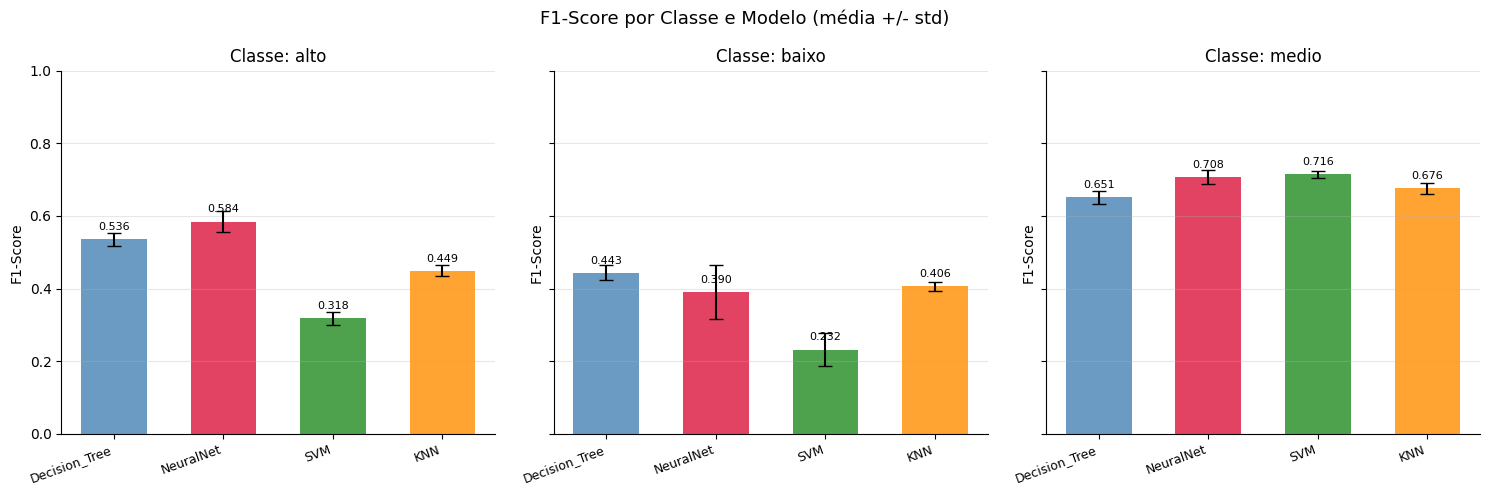

In [49]:
# F1 por classe modelo
fig, axes = plt.subplots(1, len(class_names), figsize=(5 * len(class_names), 5), sharey=True)
fig.suptitle('F1-Score por Classe e Modelo (média +/- std)', fontsize=13)

bar_colors = ['steelblue', 'crimson', 'forestgreen', 'darkorange']
model_names = list(all_metrics.keys())
x = np.arange(len(model_names))

for ax, classe in zip(axes, class_names):
    means = [all_metrics[m]['df'].loc[all_metrics[m]['df']['Classe'] == classe, 'F1_mean'].values[0]
             for m in model_names]
    stds  = [all_metrics[m]['df'].loc[all_metrics[m]['df']['Classe'] == classe, 'F1_std'].values[0]
             for m in model_names]

    bars = ax.bar(x, means, yerr=stds, capsize=5, color=bar_colors[:len(model_names)],
                  alpha=0.8, width=0.6)
    ax.set_title(f'Classe: {classe}')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('F1-Score')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

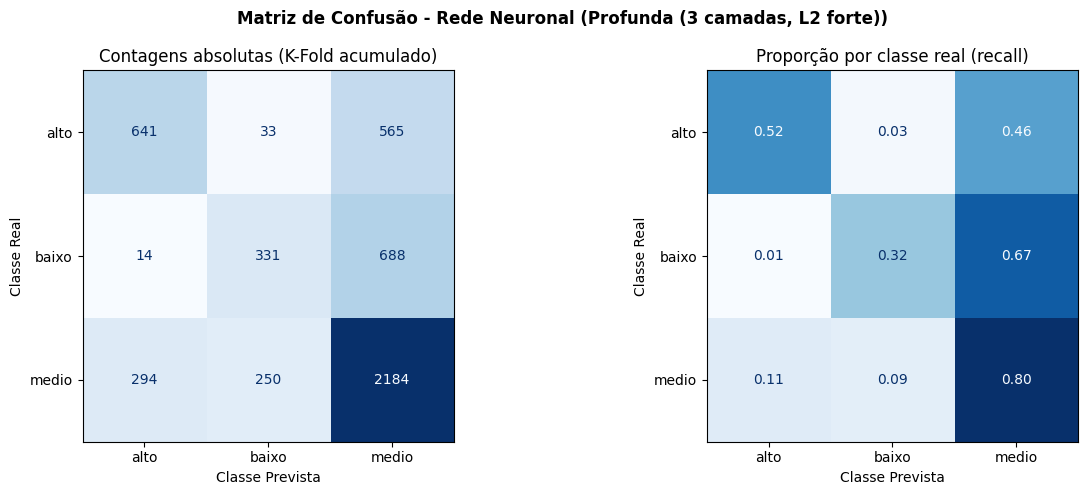


Diagnóstico por classe (recall):
      alto: 641/1239 corretas  (recall = 0.517)
     baixo: 331/1033 corretas  (recall = 0.320)
     medio: 2184/2728 corretas  (recall = 0.801)

Acurácia global (K-Fold acumulado): 0.6312


In [50]:
# Matriz de Confusão: melhor NN de Classificação
# Treina o melhor modelo NN no conjunto completo de CV (sem holdout separado)
# e avalia fold-a-fold para construir a matriz de confusão acumulada.
# Isto mantém consistência metodológica com o K-Fold já usado.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

nn_best_model = make_clf_model_full('NeuralNet')

cm_total = np.zeros((len(class_names), len(class_names)), dtype=int)

for train_idx, test_idx in kf.split(X_cv, y_cv):
    X_tr, X_te = X_cv.iloc[train_idx], X_cv.iloc[test_idx]
    y_tr, y_te = y_cv[train_idx],       y_cv[test_idx]
    clf_tmp = make_clf_model_full('NeuralNet')
    clf_tmp.fit(X_tr, y_tr)
    y_pred_fold = clf_tmp.predict(X_te)
    cm_total += confusion_matrix(y_te, y_pred_fold, labels=range(len(class_names)))

# Normalizada (% por linha = recall por classe)
cm_norm = cm_total.astype(float) / cm_total.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Matriz de Confusão - Rede Neuronal ({best_nn_clf["name"]})', fontsize=12, fontweight='bold')

disp_abs  = ConfusionMatrixDisplay(confusion_matrix=cm_total,  display_labels=class_names)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm,   display_labels=class_names)

disp_abs.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Contagens absolutas (K-Fold acumulado)')
axes[0].set_xlabel('Classe Prevista')
axes[0].set_ylabel('Classe Real')

disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.2f')
axes[1].set_title('Proporção por classe real (recall)')
axes[1].set_xlabel('Classe Prevista')
axes[1].set_ylabel('Classe Real')

plt.tight_layout()
plt.show()

# Resumo diagnóstico
print("\nDiagnóstico por classe (recall):")
for i, cls in enumerate(class_names):
    correct = cm_total[i, i]
    total   = cm_total[i, :].sum()
    print(f"  {cls:>8}: {correct}/{total} corretas  (recall = {cm_norm[i,i]:.3f})")
print(f"\nAcurácia global (K-Fold acumulado): {np.trace(cm_total)/cm_total.sum():.4f}")


### 4.3.3 - Importância de features (Árvore de Decisão)

In [51]:
# Treinar arvore
model_tree_fi = DecisionTreeClassifier(max_depth=10, random_state=CFG['random_state'])
model_tree_fi.fit(X_cv, y_cv)

fi_df = pd.DataFrame({
    'Feature':    selected_features_clf,
    'Importance': model_tree_fi.feature_importances_,
}).sort_values('Importance', ascending=False).reset_index(drop=True)

fi_df['Rank'] = fi_df.index + 1

In [52]:
top_n = 15
print_table(
    headers   = ['Rank', 'Feature', 'Importance'],
    rows      = [(row['Rank'], row['Feature'], row['Importance'])
                 for _, row in fi_df.head(top_n).iterrows()],
    title     = f"Top {top_n} Features - Importância (Árvore de Decisão)",
    float_fmt = '.4f',
)



Top 15 Features - Importância (Árvore de Decisão)
  Rank Feature                  Importance
  ──── ──────────────────────── ──────────
     1 Cap_per_Cliente              0.4587
     2 N_Clientes                   0.1646
     3 Concelho_enc                 0.0634
     4 LED_Ratio                    0.0579
     5 P_IP_Inef                    0.0505
     6 P_IP_Total                   0.0483
     7 Potência instalada [kVA]     0.0456
     8 Distrito_enc                 0.0453
     9 N_Lampadas                   0.0331
    10 N_Luminarias                 0.0326


In [53]:
corr_clf = X_clf_scaled.corrwith(pd.Series(y_clf_encoded, index=X_clf_scaled.index)).abs()
corr_df  = corr_clf.reset_index()
corr_df.columns = ['Feature', 'Correlacao']
corr_df = corr_df.sort_values('Correlacao', ascending=False).reset_index(drop=True)
corr_df['Rank_corr'] = corr_df.index + 1

print_table(
    headers   = ['Rank', 'Feature', 'Correlação |r|'],
    rows      = [(row['Rank_corr'], row['Feature'], row['Correlacao'])
                 for _, row in corr_df.head(top_n).iterrows()],
    title     = f"\nTop {top_n} Features - Correlação com utilizRede",
    float_fmt = '.4f',
)



Top 15 Features - Correlação com utilizRede
  Rank Feature                  Correlação |r|
  ──── ──────────────────────── ──────────────
     1 Potência instalada [kVA]         0.1375
     2 N_Clientes                       0.0841
     3 Cap_per_Cliente                  0.0764
     4 P_IP_Total                       0.0476
     5 N_Lampadas                       0.0389
     6 N_Luminarias                     0.0388
     7 LED_Ratio                        0.0264
     8 P_IP_Inef                        0.0125
     9 Concelho_enc                     0.0046
    10 Distrito_enc                     0.0042


In [54]:
# Importancia vs correlação
merged = fi_df[['Feature', 'Importance', 'Rank']].merge(
    corr_df[['Feature', 'Correlacao', 'Rank_corr']],
    on='Feature'
).sort_values('Rank')
merged['Δ Rank'] = (merged['Rank'] - merged['Rank_corr']).abs()

print_table(
    headers   = ['Feature', 'Rank_Imp', 'Importance', 'Rank_Corr', 'Correlação', 'Δ Rank'],
    rows      = [(row['Feature'], int(row['Rank']), row['Importance'],
                  int(row['Rank_corr']), row['Correlacao'], int(row['Δ Rank']))
                 for _, row in merged.head(top_n).iterrows()],
    title     = "\nComparação: Importância vs Correlação (Top 15 por importância)",
    float_fmt = '.4f',
)



Comparação: Importância vs Correlação (Top 15 por importância)
  Feature                  Rank_Imp Importance Rank_Corr Correlação Δ Rank
  ──────────────────────── ──────── ────────── ───────── ────────── ──────
  Cap_per_Cliente                 1     0.4587         3     0.0764      2
  N_Clientes                      2     0.1646         2     0.0841      0
  Concelho_enc                    3     0.0634         9     0.0046      6
  LED_Ratio                       4     0.0579         7     0.0264      3
  P_IP_Inef                       5     0.0505         8     0.0125      3
  P_IP_Total                      6     0.0483         4     0.0476      2
  Potência instalada [kVA]        7     0.0456         1     0.1375      6
  Distrito_enc                    8     0.0453        10     0.0042      2
  N_Lampadas                      9     0.0331         5     0.0389      4
  N_Luminarias                   10     0.0326         6     0.0388      4


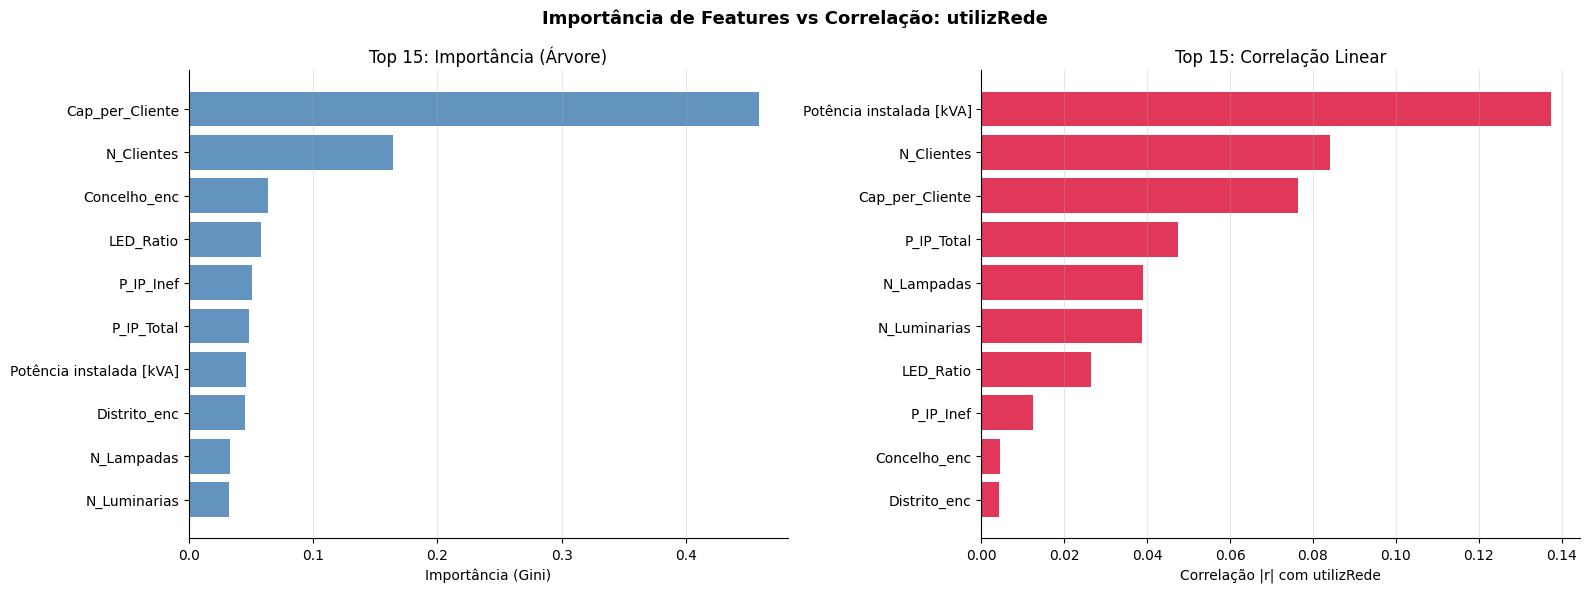

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Importância de Features vs Correlação: utilizRede', fontsize=13, fontweight='bold')

# Feature Importance
top_fi = fi_df.head(top_n)
axes[0].barh(top_fi['Feature'][::-1], top_fi['Importance'][::-1],
             color='steelblue', alpha=0.85)
axes[0].set_xlabel('Importância (Gini)')
axes[0].set_title(f'Top {top_n}: Importância (Árvore)')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Correlação
top_corr = corr_df.head(top_n)
axes[1].barh(top_corr['Feature'][::-1], top_corr['Correlacao'][::-1],
             color='crimson', alpha=0.85)
axes[1].set_xlabel('Correlação |r| com utilizRede')
axes[1].set_title(f'Top {top_n}: Correlação Linear')
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [56]:
top3_fi   = fi_df['Feature'].head(3).tolist()
top3_corr = corr_df['Feature'].head(3).tolist()
concordam = [f for f in top3_fi if f in top3_corr]
divergem  = [f for f in top3_fi if f not in top3_corr]

high_delta = merged[merged['Δ Rank'] > 5].sort_values('Δ Rank', ascending=False)

print(f"""
Top 3 por Importância : {top3_fi}
Top 3 por Correlação  : {top3_corr}

Concordância : {concordam if concordam else 'Nenhuma feature coincide no Top 3'}
Divergência  : {divergem  if divergem  else 'Nenhuma'}
""")

if not high_delta.empty:
    print(f"Features com maior divergência entre métodos (Δ Rank > 5):")
    for _, row in high_delta.head(5).iterrows():
        print(f"    {row['Feature']:<35} Imp={row['Rank']:>2}º  Corr={row['Rank_corr']:>2}º  Δ={int(row['Δ Rank'])}")


Top 3 por Importância : ['Cap_per_Cliente', 'N_Clientes', 'Concelho_enc']
Top 3 por Correlação  : ['Potência instalada [kVA]', 'N_Clientes', 'Cap_per_Cliente']

Concordância : ['Cap_per_Cliente', 'N_Clientes']
Divergência  : ['Concelho_enc']

Features com maior divergência entre métodos (Δ Rank > 5):
    Concelho_enc                        Imp= 3º  Corr= 9º  Δ=6
    Potência instalada [kVA]            Imp= 7º  Corr= 1º  Δ=6


### 4.3.4 - Testes de significância estatística (Classificação)

In [57]:
best_models_clf = sorted(results_clf, key=lambda k: results_clf[k]['F1_mean'], reverse=True)[:2]
m1_name, m2_name = best_models_clf

print(f"\nModelos comparados: {m1_name} vs {m2_name}")
print(f"\t{m1_name:<15} F1 = {results_clf[m1_name]['F1_mean']:.4f} +/- {results_clf[m1_name]['F1_std']:.4f}")
print(f"\t{m2_name:<15} F1 = {results_clf[m2_name]['F1_mean']:.4f} +/- {results_clf[m2_name]['F1_std']:.4f}")


Modelos comparados: NeuralNet vs Decision_Tree
	NeuralNet       F1 = 0.6120 +/- 0.0113
	Decision_Tree   F1 = 0.5798 +/- 0.0158


In [58]:
def f1_per_fold(model, X, y, kf):
    scores = []
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx],      y[test_idx]
        model.fit(X_train, y_train)
        scores.append(f1_score(y_test, model.predict(X_test),
                               average='weighted', zero_division=0))
    return np.array(scores)

f1_m1 = f1_per_fold(make_clf_model_full(m1_name), X_cv, y_cv, kf)
f1_m2 = f1_per_fold(make_clf_model_full(m2_name), X_cv, y_cv, kf)

print_table(
    headers = ['Fold'] + [f'{m1_name} F1', f'{m2_name} F1', 'Diferença'],
    rows    = [(i + 1, f1_m1[i], f1_m2[i], f1_m1[i] - f1_m2[i])
               for i in range(len(f1_m1))],
    title   = "\nF1-Score por Fold",
)



F1-Score por Fold
  Fold NeuralNet F1 Decision_Tree F1 Diferença
  ──── ──────────── ──────────────── ─────────
     1       0.6226           0.6021    0.0205
     2       0.6171           0.5672    0.0499
     3       0.5964           0.5703    0.0261


In [59]:
# Com apenas k=5 folds, Shapiro-Wilk é o teste adequado (n < 50)
_, p_m1 = shapiro(f1_m1)
_, p_m2 = shapiro(f1_m2)

normal_m1 = p_m1 > 0.05
normal_m2 = p_m2 > 0.05

print_table(
    headers = ['Modelo', 'p-value', 'Resultado'],
    rows    = [
        (m1_name, p_m1, 'Normal' if normal_m1 else 'Não-normal'),
        (m2_name, p_m2, 'Normal' if normal_m2 else 'Não-normal'),
    ],
    title   = "\n1. Teste de Normalidade Shapiro-Wilk (α = 0.05)",
)



1. Teste de Normalidade Shapiro-Wilk (α = 0.05)
  Modelo        p-value Resultado
  ───────────── ─────── ─────────
  NeuralNet      0.3804 Normal   
  Decision_Tree  0.1523 Normal   


In [60]:
# Nota: com k=5 folds o Wilcoxon pode não ter potência suficiente.
# O t-test pareado é mais robusto para amostras pequenas quando a
# normalidade é razoável: usamos sempre t-test pareado e reportamos
# o Wilcoxon como verificação quando não-normal.
stat_t, p_t = ttest_rel(f1_m1, f1_m2)

try:
    stat_w, p_w = wilcoxon(f1_m1, f1_m2)
    wilcoxon_ok = True
except Exception as e:
    stat_w, p_w = None, None
    wilcoxon_ok = False
    print(f"Wilcoxon indisponível: {e}")

if normal_m1 and normal_m2:
    test_name     = "t-test Pareado"
    stat, p_val   = stat_t, p_t
    justification = "Ambas as distribuições são normais: teste paramétrico."
else:
    test_name     = "Wilcoxon Signed-Rank"
    stat, p_val   = (stat_w, p_w) if wilcoxon_ok else (stat_t, p_t)
    justification = (
        "Pelo menos uma distribuição não-normal: teste não-paramétrico (Wilcoxon)."
        if wilcoxon_ok else
        "Pelo menos uma distribuição não-normal mas Wilcoxon indisponível: t-test como fallback."
    )

significativo = p_val < 0.05

print_table(
    headers = ['Teste', 'Estatística', 'p-value', 'Resultado'],
    rows    = [
        ('t-test Pareado', stat_t, p_t,
         'Significativo' if p_t < 0.05 else 'Não significativo'),
        ('Wilcoxon Signed-Rank',
         stat_w if wilcoxon_ok else 'N/A',
         p_w    if wilcoxon_ok else 'N/A',
         ('Significativo' if p_w < 0.05 else 'Não significativo') if wilcoxon_ok else 'N/A (poucos folds)'),
    ],
    title = "\nTestes de Diferença (α = 0.05)",
)
print(f"\nTeste selecionado : {test_name}")
print(f"{justification}")



Testes de Diferença (α = 0.05)
  Teste                Estatística p-value Resultado        
  ──────────────────── ─────────── ─────── ─────────────────
  t-test Pareado            3.5689  0.0703 Não significativo
  Wilcoxon Signed-Rank      0.0000  0.2500 Não significativo

Teste selecionado : t-test Pareado
Ambas as distribuições são normais: teste paramétrico.


In [61]:
melhor_clf = m1_name if results_clf[m1_name]['F1_mean'] > results_clf[m2_name]['F1_mean'] else m2_name
diff_f1    = abs(results_clf[m1_name]['F1_mean'] - results_clf[m2_name]['F1_mean'])

print(f"""
{m1_name:<15} F1 = {results_clf[m1_name]['F1_mean']:.4f} +/- {results_clf[m1_name]['F1_std']:.4f}
{m2_name:<15} F1 = {results_clf[m2_name]['F1_mean']:.4f} +/- {results_clf[m2_name]['F1_std']:.4f}
Diferença absoluta de F1 : {diff_f1:.4f}
""")

if significativo:
    print(f"\tA diferença é estatisticamente significativa (p={p_val:.4f} < 0.05).")
    print(f"\tO modelo com melhor desempenho é {melhor_clf}.")
else:
    print(f"\tA diferença NÃO é estatisticamente significativa (p={p_val:.4f} ≥ 0.05).")
    print(f"\tAmbos os modelos são equivalentes: {melhor_clf} tem F1 ligeiramente")
    print(f"\tsuperior mas a diferença pode ser devida ao acaso.")
    if diff_f1 < 0.01:
        print(f"\tA diferença de {diff_f1:.4f} é também praticamente irrelevante.")

print(f"\nMelhor modelo de classificação: {melhor_clf}")
best_clf_model = melhor_clf


NeuralNet       F1 = 0.6120 +/- 0.0113
Decision_Tree   F1 = 0.5798 +/- 0.0158
Diferença absoluta de F1 : 0.0322

	A diferença NÃO é estatisticamente significativa (p=0.0703 ≥ 0.05).
	Ambos os modelos são equivalentes: NeuralNet tem F1 ligeiramente
	superior mas a diferença pode ser devida ao acaso.

Melhor modelo de classificação: NeuralNet


### 4.3.5 - Comparação e curvas de aprendizagem

In [62]:
print_table(
    headers = ['Modelo', 'Accuracy', '+/-', 'Precision', '+/-', 'Recall', '+/-', 'F1', '+/-'],
    rows    = [
        (
            name,
            res['Accuracy_mean'],  res['Accuracy_std'],
            res['Precision_mean'], res['Precision_std'],
            res['Recall_mean'],    res['Recall_std'],
            res['F1_mean'],        res['F1_std'],
        )
        for name, res in results_clf.items()
    ],
    title = "\nMétricas Globais: Todos os Modelos",
)

# Identificar melhor e pior por cada métrica
metrics_map = {
    'Accuracy':  ('Accuracy_mean',  True),
    'Precision': ('Precision_mean', True),
    'Recall':    ('Recall_mean',    True),
    'F1-Score':  ('F1_mean',        True),
}

print("\nMelhor e pior por métrica:")
print(f"  {'Métrica':<12} {'Melhor':<18} {'Pior':<18}")
print(f"  {'─'*12} {'─'*18} {'─'*18}")
for metric, (key, higher_is_better) in metrics_map.items():
    ranked  = sorted(results_clf.items(), key=lambda x: x[1][key], reverse=higher_is_better)
    melhor  = ranked[0]
    pior    = ranked[-1]
    print(f"  {metric:<12} {melhor[0]:<18} {pior[0]:<18}")

best_overall  = max(results_clf, key=lambda k: results_clf[k]['F1_mean'])
worst_overall = min(results_clf, key=lambda k: results_clf[k]['F1_mean'])
print(f"\nMelhor global (F1): {best_overall}")
print(f"Pior global  (F1): {worst_overall}")



Métricas Globais: Todos os Modelos
  Modelo        Accuracy    +/- Precision    +/- Recall    +/-     F1    +/-
  ───────────── ──────── ────── ───────── ────── ────── ────── ────── ──────
  Decision_Tree   0.5828 0.0159    0.5794 0.0149 0.5828 0.0159 0.5798 0.0158
  NeuralNet       0.6312 0.0107    0.6287 0.0078 0.6312 0.0107 0.6120 0.0113
  SVM             0.5916 0.0107    0.6295 0.0112 0.5916 0.0107 0.5171 0.0176
  KNN             0.5808 0.0143    0.5701 0.0129 0.5808 0.0143 0.5641 0.0166

Melhor e pior por métrica:
  Métrica      Melhor             Pior              
  ──────────── ────────────────── ──────────────────
  Accuracy     NeuralNet          KNN               
  Precision    SVM                KNN               
  Recall       NeuralNet          KNN               
  F1-Score     NeuralNet          SVM               

Melhor global (F1): NeuralNet
Pior global  (F1): SVM


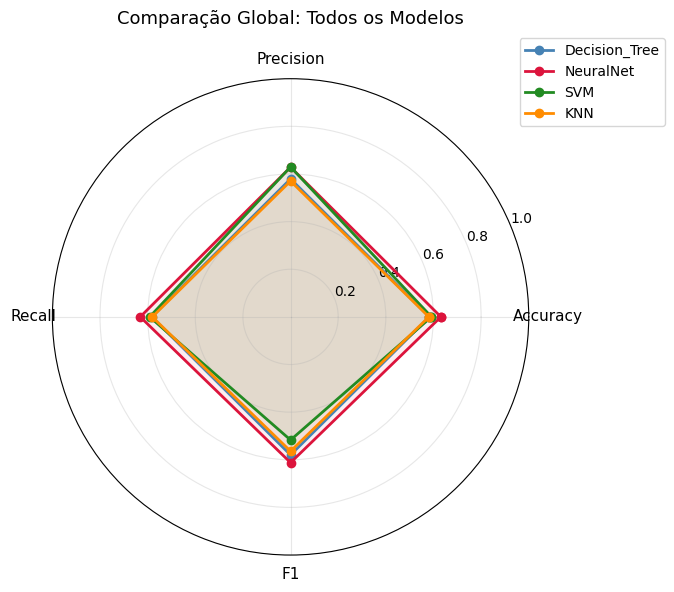

In [63]:
radar_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
radar_keys    = ['Accuracy_mean', 'Precision_mean', 'Recall_mean', 'F1_mean']
angles        = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles       += angles[:1]   # fechar o polígono

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors  = ['steelblue', 'crimson', 'forestgreen', 'darkorange']

for (name, res), color in zip(results_clf.items(), colors):
    values  = [res[k] for k in radar_keys]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=name, color=color)
    ax.fill(angles, values, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Comparação Global: Todos os Modelos', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



  NeuralNet (Melhor):
    F1 Treino   : 0.6237
    F1 Validação: 0.5922
    Gap         : -0.0315
    . Treino adequado: curvas convergem

  SVM (Pior):
    F1 Treino   : 0.5189
    F1 Validação: 0.5152
    Gap         : -0.0038
    . Treino adequado: curvas convergem


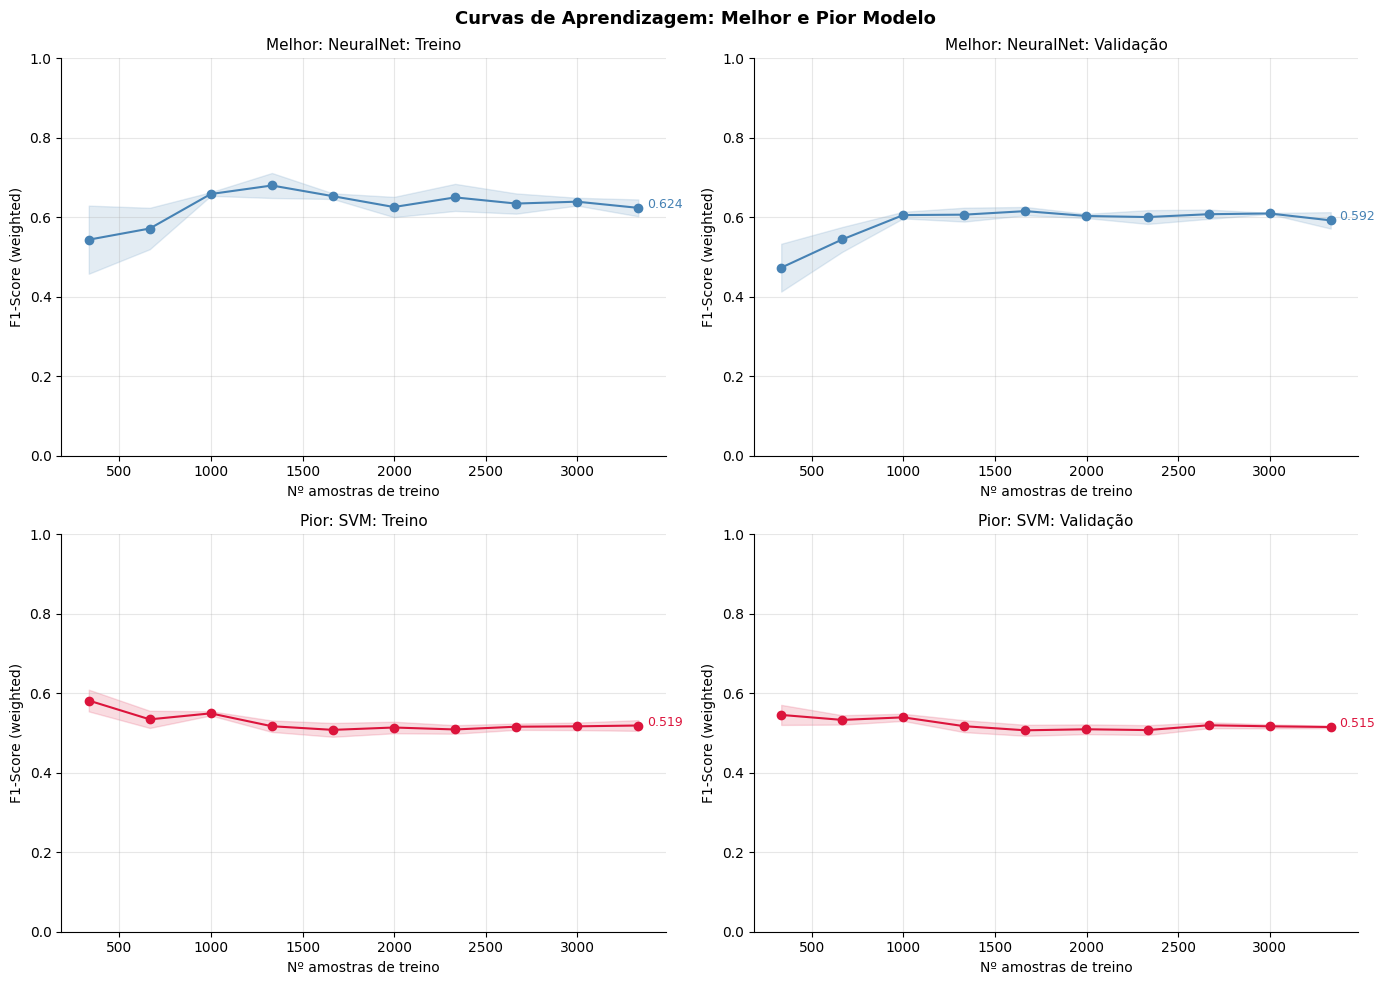

In [64]:
if CFG['sample_lc']:
    idx_lc = np.random.default_rng(CFG['random_state']).choice(
                len(X_clf_scaled), size=CFG['sample_lc'], replace=False)
    X_lc = X_clf_scaled.iloc[idx_lc]
    y_lc = y_clf_encoded[idx_lc]
else:
    X_lc, y_lc = X_clf_scaled, y_clf_encoded

lc_data_clf  = {}
models_to_lc = [best_overall, worst_overall]

fig, axes = plt.subplots(len(models_to_lc), 2,
                         figsize=(14, 5 * len(models_to_lc)))
if len(models_to_lc) == 1:
    axes = np.array([axes])
fig.suptitle('Curvas de Aprendizagem: Melhor e Pior Modelo', fontsize=13, fontweight='bold')

for row, model_name in enumerate(models_to_lc):
    model = make_clf_model_full(model_name)
    label = "Melhor" if model_name == best_overall else "Pior"

    train_sizes, train_scores, val_scores = learning_curve(
        model, X_lc, y_lc,
        cv          = CFG['kfold_splits'],
        train_sizes = np.linspace(0.1, 1.0, 10),
        scoring     = 'f1_weighted',
        n_jobs      = -1,
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    lc_data_clf[model_name] = {
        'train_sizes': train_sizes,
        'train_scores': train_scores,
        'val_scores':   val_scores,
    }

    ax_train = axes[row, 0]
    ax_val   = axes[row, 1]

    ax_train.set_title(f'{label}: {model_name}: Treino', fontsize=11)
    ax_val.set_title(  f'{label}: {model_name}: Validação', fontsize=11)

    color = 'steelblue' if model_name == best_overall else 'crimson'

    ax_train.plot(train_sizes, train_mean, 'o-', color=color)
    ax_train.fill_between(train_sizes,
                          train_mean - train_std, train_mean + train_std,
                          alpha=0.15, color=color)

    ax_val.plot(train_sizes, val_mean, 'o-', color=color)
    ax_val.fill_between(train_sizes,
                        val_mean - val_std, val_mean + val_std,
                        alpha=0.15, color=color)

    # Anotação valor final
    for ax, mean in [(ax_train, train_mean), (ax_val, val_mean)]:
        ax.annotate(f'{mean[-1]:.3f}',
                    xy=(train_sizes[-1], mean[-1]),
                    xytext=(6, 0), textcoords='offset points',
                    fontsize=9, color=color)
        ax.set_xlabel('Nº amostras de treino')
        ax.set_ylabel('F1-Score (weighted)')
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Diagnóstico
    gap = val_mean[-1] - train_mean[-1]
    if abs(gap) < 0.05:
        diag = ". Treino adequado: curvas convergem"
    elif train_mean[-1] > val_mean[-1] + 0.1:
        diag = "! Overfitting: treino muito melhor que validação"
    else:
        diag = "! Underfitting: F1 baixo em treino e validação"

    print(f"\n  {model_name} ({label}):")
    print(f"    F1 Treino   : {train_mean[-1]:.4f}")
    print(f"    F1 Validação: {val_mean[-1]:.4f}")
    print(f"    Gap         : {gap:.4f}")
    print(f"    {diag}")

plt.tight_layout()
plt.show()

In [65]:
print(f"""
Melhor modelo : {best_overall}
\tF1={results_clf[best_overall]['F1_mean']:.4f}  Acc={results_clf[best_overall]['Accuracy_mean']:.4f}
\tmaior F1-Score weighted, equilibrado entre
\tclasses. As curvas de aprendizagem indicam {'convergência adequada' if
abs(lc_data_clf[best_overall]['val_scores'].mean(axis=1)[-1] -
    lc_data_clf[best_overall]['train_scores'].mean(axis=1)[-1]) < 0.05
else '\talgum overfitting: gap entre treino e validação'}.
Pior modelo   : {worst_overall}
\tF1={results_clf[worst_overall]['F1_mean']:.4f}  Acc={results_clf[worst_overall]['Accuracy_mean']:.4f}
\tmenor F1-Score global. As curvas de aprendizagem
\trevelam {'convergência mas a níveis de F1 mais baixos, sugerindo underfitting' if
  results_clf[worst_overall]['F1_mean'] < 0.6
  else '\tinstabilidade entre folds (std elevado), indicando sensibilidade aos dados de treino'}.
""")


Melhor modelo : NeuralNet
	F1=0.6120  Acc=0.6312
	maior F1-Score weighted, equilibrado entre
	classes. As curvas de aprendizagem indicam convergência adequada.
Pior modelo   : SVM
	F1=0.5171  Acc=0.5916
	menor F1-Score global. As curvas de aprendizagem
	revelam convergência mas a níveis de F1 mais baixos, sugerindo underfitting.



## Persistencia de dados

In [66]:
from datetime import datetime
import os
import joblib
import pickle

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

profile_tag = f"{CFG['name'].replace(' ', '_')}"
os.makedirs(os.path.join(RESULTS_DIR, profile_tag), exist_ok=True)

results_path = os.path.join(RESULTS_DIR, profile_tag, "results.pkl")

joblib.dump(model_lr, os.path.join(RESULTS_DIR, profile_tag, f"{profile_tag}_model_lr.pkl"))
joblib.dump(model_tree, os.path.join(RESULTS_DIR, profile_tag, f"{profile_tag}_model_tree.pkl"))

joblib.dump(best_svm, os.path.join(RESULTS_DIR, profile_tag, f"{profile_tag}_model_svm.pkl"))
joblib.dump(best_nn, os.path.join(RESULTS_DIR, profile_tag, f"{profile_tag}_model_nn.pkl"))
joblib.dump(best_knn, os.path.join(RESULTS_DIR, profile_tag, f"{profile_tag}_model_knn.pkl"))

joblib.dump(scaler, os.path.join(RESULTS_DIR, profile_tag, f"{profile_tag}_scaler.pkl"))

with open(results_path, 'wb') as f:
    pickle.dump(results_all, f)

clf_results_path = os.path.join(RESULTS_DIR, profile_tag, "results_clf.pkl")
with open(clf_results_path, 'wb') as f:
    pickle.dump(results_clf, f)

curves_to_save = {
    'loss_curves': loss_curves,
    'learning_curves': {
        model_name: {
            'train_sizes': train_sizes,
            'train_mae': train_mae,
            'val_mae': val_mae,
        }
        for model_name in best_models_reg
    },
    'nn_loss_curves': loss_curves_clf,
    'nn_learning_curves': lc_data_clf,
}

with open(os.path.join(RESULTS_DIR, profile_tag, f"{profile_tag}_curves.pkl"), 'wb') as f:
    pickle.dump(curves_to_save, f)

# Criar um DataFrame auxiliar com os mapeamentos reais gerados no treino
mapping_df = pd.DataFrame({
    'Distrito': le_distrito.classes_[df['Distrito_enc']],
    'Concelho': le_concelho.classes_[df['Concelho_enc']],
    'Distrito_enc': df['Distrito_enc'],
    'Concelho_enc': df['Concelho_enc']
}).drop_duplicates()

# Guardar a tabela relacional de IDs para a interface
joblib.dump(mapping_df, os.path.join(RESULTS_DIR, profile_tag, f"{profile_tag}_geo_mapping.pkl"))

print(f"\n  Dados em cache guardados com sucesso em: {os.path.join(RESULTS_DIR, profile_tag)}")


  Dados em cache guardados com sucesso em: results/Perfil_Leve


In [67]:
# Escrever report
lines = []
lines.append(f"# Relatório de Resultados: {CFG['name']}")
lines.append(f"**Data:** {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")

# Regressão
lines.append("## Regressão: PFolga_PTD\n")

lines.append("### Métricas (K-Fold CV)")
lines.append(f"| Modelo | MAE | +/-MAE | RMSE | +/-RMSE |")
lines.append(f"|--------|-----|------|------|-------|")
for model_name, res in results_all.items():
    lines.append(f"| {model_name} | {res['mae_mean']:.4f} | {res['mae_std']:.4f} "
                 f"| {res['rmse_mean']:.4f} | {res['rmse_std']:.4f} |")

name_map = {
    "Decision_Tree": "Tree",
    "NeuralNet": "NeuralNet",
    "Linear": "Linear",
    "SVM": "SVM"
}

m1_key = name_map[m1_name]
m2_key = name_map[m2_name]

lines.append("\n### Diagnóstico: Curvas de Aprendizagem")
for model_name, d in diagnostics.items():
    lines.append(f"\n#### {model_name}")
    lines.append(f"| | MAE (kVA) |")
    lines.append(f"|---|---|")
    lines.append(f"| Treino    | {d['final_train']:.4f} |")
    lines.append(f"| Validação | {d['final_val']:.4f} |")
    lines.append(f"| Gap       | {d['gap']:.4f} |")
    lines.append(f"\n> {d['diagnosis']}  ")
    lines.append(f"> {d['detail']}")

lines.append("\n### Teste de Significância Estatística")
lines.append(f"**Modelos:** {m1_name} vs {m2_name}  ")
lines.append(f"**Teste:** {test_name} (α = 0.05)  ")
lines.append(f"**Justificação:** {justification}\n")
lines.append(f"| | {m1_name} | {m2_name} |")
lines.append(f"|---|---|---|")
lines.append(
    f"| MAE | "
    f"{mae_m1:.4f} +/- {results_all[m1_key]['mae_std']:.4f} | "
    f"{mae_m2:.4f} +/- {results_all[m2_key]['mae_std']:.4f} |"
)
lines.append(f"| Estatística | {stat:.4f} | / |")
lines.append(f"| p-value     | {p_val:.4f} | / |")
lines.append(f"| Resultado   | {'**Significativo:**' if significativo else 'Não significativo'} | / |")
lines.append(f"\n**Melhor modelo (regressão):** {melhor[0]}  ")
if significativo:
    lines.append(f"A diferença é estatisticamente significativa (p={p_val:.4f} < 0.05).")
else:
    lines.append(f"A diferença não é estatisticamente significativa (p={p_val:.4f} ≥ 0.05).  ")
    lines.append(f"Ambos os modelos são equivalentes: {melhor[0]} tem MAE ligeiramente inferior.")

# Classificação
lines.append("\n---\n")
lines.append("## Classificação: utilizRede\n")

lines.append("### Métricas Globais (K-Fold CV)")
lines.append(f"| Modelo | Accuracy | +/-Acc | Precision | +/-Prec | Recall | +/-Rec | F1 | +/-F1 |")
lines.append(f"|--------|----------|------|-----------|-------|--------|------|----|-----|")
for model_name, res in results_clf.items():
    lines.append(f"| {model_name} "
                 f"| {res['Accuracy_mean']:.4f} | {res['Accuracy_std']:.4f} "
                 f"| {res['Precision_mean']:.4f} | {res['Precision_std']:.4f} "
                 f"| {res['Recall_mean']:.4f} | {res['Recall_std']:.4f} "
                 f"| {res['F1_mean']:.4f} | {res['F1_std']:.4f} |")

lines.append("\n### Métricas por Classe")
for model_name, data in all_metrics.items():
    lines.append(f"\n#### {model_name}  (Accuracy: {data['acc_mean']:.4f} +/- {data['acc_std']:.4f})")
    lines.append(f"| Classe | Precision | +/-Prec | Recall | +/-Rec | F1 | +/-F1 |")
    lines.append(f"|--------|-----------|-------|--------|------|----|-----|")
    for _, row in data['df'].iterrows():
        lines.append(f"| {row['Classe']} "
                     f"| {row['Precision_mean']:.4f} | {row['Precision_std']:.4f} "
                     f"| {row['Recall_mean']:.4f} | {row['Recall_std']:.4f} "
                     f"| {row['F1_mean']:.4f} | {row['F1_std']:.4f} |")

lines.append("\n### Melhor e Pior Modelo por Métrica")
lines.append(f"| Métrica | Melhor | Pior |")
lines.append(f"|---------|--------|------|")
for metric, (key, _) in metrics_map.items():
    ranked = sorted(results_clf.items(), key=lambda x: x[1][key], reverse=True)
    lines.append(f"| {metric} | {ranked[0][0]} | {ranked[-1][0]} |")

lines.append(f"\n### Curvas de Aprendizagem")
for model_name in [best_overall, worst_overall]:
    label      = "Melhor" if model_name == best_overall else "Pior"
    lc         = lc_data_clf[model_name]
    train_mean = lc['train_scores'].mean(axis=1)
    val_mean   = lc['val_scores'].mean(axis=1)
    gap        = val_mean[-1] - train_mean[-1]

    if abs(gap) < 0.05:
        diag = "Treino adequado: curvas convergem"
    elif train_mean[-1] > val_mean[-1] + 0.1:
        diag = "Overfitting: treino muito melhor que validação"
    else:
        diag = "Underfitting: F1 baixo em treino e validação"

    lines.append(f"\n#### {label}: {model_name}")
    lines.append(f"| | F1 (weighted) |")
    lines.append(f"|---|---|")
    lines.append(f"| Treino    | {train_mean[-1]:.4f} |")
    lines.append(f"| Validação | {val_mean[-1]:.4f} |")
    lines.append(f"| Gap       | {gap:.4f} |")
    lines.append(f"\n> {diag}")

lines.append("\n### Teste de Significância Estatística")
lines.append(f"**Modelos:** {m1_name} vs {m2_name}  ")  # reutiliza vars da classificação
lines.append(f"**Teste:** {test_name} (α = 0.05)  ")
lines.append(f"**Justificação:** {justification}\n")
lines.append(f"| | {m1_name} | {m2_name} |")
lines.append(f"|---|---|---|")
lines.append(f"| F1          | {results_clf[m1_name]['F1_mean']:.4f} +/- {results_clf[m1_name]['F1_std']:.4f} "
             f"| {results_clf[m2_name]['F1_mean']:.4f} +/- {results_clf[m2_name]['F1_std']:.4f} |")
lines.append(f"| Estatística | {stat:.4f} | / |")
lines.append(f"| p-value     | {p_val:.4f} | / |")
lines.append(f"| Resultado   | {'**Significativo:**' if significativo else 'Não significativo'} | / |")
lines.append(f"\n**Melhor modelo (classificação):** {best_clf_model[0]}")

report_path = os.path.join(RESULTS_DIR, profile_tag, "README.md")
with open(report_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))
print(f"Relatório guardado em '{report_path}'")

Relatório guardado em 'results/Perfil_Leve/README.md'
